## Digital Finance, Forecasting & Analytics Platform

## Module 4.5 — FP&A Variance Intelligence & Revenue Bridge Analysis

---

**Purpose:**  
Decompose the gap between actual and forecast revenue across Price, Volume, and Mix, creating a granular FP&A intelligence layer for executive decision support.

**Scope:**  
2023–2024 fiscal years, 9 analytical segments — 3 channels × 3 products — at monthly granularity.

**Analytical Framework:**

Revenue Variance = Price Effect + Volume Effect + Mix Effect

| Effect | Formula | FP&A Interpretation |
|---|---|---|
| Price Effect | `Σ (P_actual - P_forecast) × Q_actual` | Price realization versus plan |
| Volume Effect | `(Q_total_actual - Q_total_forecast) × P_avg_forecast` | Demand variance versus plan |
| Mix Effect | `Revenue Variance - Price Effect - Volume Effect` | Structural shift across channels and products |

**Data Sources:**

| Source | Content | Scope |
|---|---|---|
| `fact_price_volume` | Actual and forecast price/volume by channel/product/scenario | 2023–2024 |
| `final_23_forecast.csv` | Monthly revenue actual vs forecast and scenarios | 2023–2024 |
| SQL forecast views | P&L, balance sheet and cash flow forecast views | 2023–2024 |
| SQL actual views | Actual financial statements and supporting facts | Historical / actuals |

**Scenario Logic:**

| ScenarioKey | Use |
|---:|---|
| `1` | Actual price and volume |
| `3` | Forecast price and volume |

**Core Outputs:**

- Revenue variance bridge by year and month.
- Price, volume and mix variance by channel/product.
- Contribution analysis by segment.
- Reconciliation between bridge revenue and actual/forecast revenue.
- Executive FP&A summary for decision support.


### 1 — Setup & Imports

In [12]:
import os
import logging
import warnings
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
pd.set_option('display.max_columns', 50)

BASE_DIR = Path(r'C:\Users\gusta\Documents\Codex')
OUTPUT_DIR = BASE_DIR / 'forecast_output'
OUTPUT_DIR.mkdir(exist_ok=True)
SCHEMA = 'finance_ifrs_dw'

sns.set_theme(style="whitegrid", context="talk")

# Consulting-style palette
NAVY    = "#1F3A5F"
BLUE    = "#2F80ED"
TEAL    = "#2D9CDB"
GREEN   = "#219653"
RED     = "#DC2626"
ORANGE  = "#F2994A"
GREY    = "#8A94A6"
DARK    = "#263238"
LIGHT   = "#E5E7EB"
PURPLE  = "#6C5CE7"

CH1 =  "#1F3A5F"
CH2 = "#9CA3AF"
CH3 = "#6FA8DC"

PR1 =  "#4B3F72"
PR2 =  "#9CA3AF"
PR3 =  "#B8A1E3"

CONSULTING_PALETTE = [NAVY, BLUE, TEAL, GREEN, ORANGE, RED, GREY, PURPLE]
sns.set_palette(CONSULTING_PALETTE)

# Channel colors
CH_COLORS = {"Direct": CH1, "Online": CH2, "Retail": CH3,}

# Product colors
PR_COLORS = {"Industrial": PR1, "Automotive": PR2, "Electric": PR3,}

# Scenario colors
SC_COLORS = { "Stress (P10)": RED, "Pessimistic (P30)": ORANGE, "Base Forecast": BLUE, "Optimistic (P70)": GREEN,}

### 2 — Logging

In [13]:
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s [%(levelname)s] %(message)s',
    handlers=[
        logging.FileHandler(BASE_DIR / 'ifrs_pipeline.log', mode='a'),
        logging.StreamHandler()
    ],
    force=True
)
log = logging.getLogger(__name__)
log.info('Module 4.5 - FP&A Bridge Analysis - START')

2026-04-15 17:32:09,546 [INFO] Module 4.5 - FP&A Bridge Analysis - START


### 3 — Database Connection

In [14]:
load_dotenv(BASE_DIR / '.env')

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}/{os.getenv('DB_NAME')}",
    pool_pre_ping=True
)

with engine.connect() as conn:
    conn.execute(text('SELECT 1'))

DB_AVAILABLE = True
log.info('Database connection established.')
print('Database connection established.')

2026-04-15 17:32:09,599 [INFO] Database connection established.


Database connection established.


### 4 — Data Loading

**Dimension mappings (validated against fact_price_volume)**

| Key | Value | Mapping in reg.csv |
|---|---|---|
| ChannelKey 1 | Direct | prefix `D` |
| ChannelKey 2 | Retail | prefix `R` |
| ChannelKey 3 | Online | prefix `O` |
| ProductKey 1 | Industrial | suffix `I` |
| ProductKey 2 | Automotive | suffix `A` |
| ProductKey 3 | Electric | suffix `E` |

In [15]:
# Dimension maps
CHANNEL_MAP = {'D': (1, 'Direct'), 'R': (2, 'Retail'), 'O': (3, 'Online')}
PRODUCT_MAP = {'I': (1, 'Industrial'), 'A': (2, 'Automotive'), 'E': (3, 'Electric')}
CHANNEL_KEY = {1: 'Direct', 2: 'Retail', 3: 'Online'}
PRODUCT_KEY = {1: 'Industrial', 2: 'Automotive', 3: 'Electric'}

# Local file intentionally retained for scenario envelope from Module 4.2.
f23_raw = pd.read_csv('forecast_output/final_23_forecast.csv')

# SQL fact sources
pv_raw = pd.read_sql(text(f'''
    SELECT
        pv.datekey AS "DateKey",
        pv.channelkey AS "ChannelKey",
        pv.productkey AS "ProductKey",
        pv.price AS "Price",
        pv.units AS "Units",
        pv.scenariokey AS "ScenarioKey",
        d.year AS "Year",
        d.month AS "Month"
    FROM {SCHEMA}.fact_price_volume pv
    JOIN {SCHEMA}.dim_date d ON pv.datekey = d.datekey
    WHERE pv.scenariokey IN (1, 3)
      AND d.year IN (2023, 2024)
    ORDER BY pv.datekey, pv.scenariokey, pv.channelkey, pv.productkey
'''), engine)

sales_raw = pd.read_sql(text(f'''
    SELECT
        fs.datekey AS "DateKey",
        fs.scenariokey AS "ScenarioKey",
        d.year AS "Year",
        d.month AS "Month",
        ch.channelname AS "Channel",
        p.productname AS "Product",
        SUM(fs.amount) AS "Revenue"
    FROM {SCHEMA}.fact_sales fs
    JOIN {SCHEMA}.dim_date d ON fs.datekey = d.datekey
    JOIN {SCHEMA}.dim_channel ch ON fs.channelkey = ch.channelkey
    JOIN {SCHEMA}.dim_product p ON fs.productkey = p.productkey
    WHERE fs.scenariokey IN (1, 3)
      AND d.year IN (2023, 2024)
    GROUP BY fs.datekey, fs.scenariokey, d.year, d.month, ch.channelname, p.productname
    ORDER BY fs.datekey, fs.scenariokey, ch.channelname, p.productname
'''), engine)

pl_annual_actual = pd.read_sql(f'SELECT * FROM {SCHEMA}.vw_pl_annual WHERE year IN (2023, 2024) ORDER BY year', engine)
pl_annual_fcst   = pd.read_sql(f'SELECT * FROM {SCHEMA}.vw_pl_annual_forecast ORDER BY year', engine)
pl_monthly_actual = pd.read_sql(f'SELECT * FROM {SCHEMA}.vw_pl_monthly WHERE year IN (2023, 2024) ORDER BY datekey', engine)
pl_monthly_fcst   = pd.read_sql(f'SELECT * FROM {SCHEMA}.vw_pl_monthly_forecast ORDER BY datekey', engine)

cf_annual_actual = pd.read_sql(f'SELECT * FROM {SCHEMA}.vw_cf_annual WHERE year IN (2023, 2024) ORDER BY year', engine)
cf_annual_fcst   = pd.read_sql(f'SELECT * FROM {SCHEMA}.vw_cf_annual_forecast ORDER BY year', engine)
bs_annual_actual = pd.read_sql(f'SELECT * FROM {SCHEMA}.vw_bs_annual WHERE year IN (2023, 2024) ORDER BY year', engine)
bs_annual_fcst   = pd.read_sql(f'SELECT * FROM {SCHEMA}.vw_bs_annual_forecast ORDER BY year', engine)

pv_actual_raw = pv_raw[pv_raw['ScenarioKey'] == 1].copy()
pv_fcst_raw   = pv_raw[pv_raw['ScenarioKey'] == 3].copy()

log.info('SQL sources loaded. final_23_forecast.csv retained for scenario envelope.')
print(f'fact_price_volume actual  : {len(pv_actual_raw):>4} rows ({pv_actual_raw.DateKey.min()}→{pv_actual_raw.DateKey.max()})')
print(f'fact_price_volume forecast: {len(pv_fcst_raw):>4} rows ({pv_fcst_raw.DateKey.min()}→{pv_fcst_raw.DateKey.max()})')
print(f'fact_sales                : {len(sales_raw):>4} rows')
print(f'P&L annual actual/forecast: {len(pl_annual_actual)} / {len(pl_annual_fcst)} rows')
print(f'f23_forecast CSV          : {len(f23_raw):>4} rows ({f23_raw.Date.min()}→{f23_raw.Date.max()})')

2026-04-15 17:32:09,704 [INFO] SQL sources loaded. final_23_forecast.csv retained for scenario envelope.


fact_price_volume actual  :  216 rows (202301→202412)
fact_price_volume forecast:  216 rows (202301→202412)
fact_sales                :  432 rows
P&L annual actual/forecast: 2 / 2 rows
f23_forecast CSV          :   24 rows (202301→202412)


### 5 — Bridge Data Construction

In [16]:
def build_pv_from_sql(pv: pd.DataFrame, scenario: int, suffix: str) -> pd.DataFrame:
    # Prepare SQL fact_price_volume as bridge-ready actual or forecast driver table.
    df = pv[pv['ScenarioKey'] == scenario].copy()
    df['Channel'] = df['ChannelKey'].map(CHANNEL_KEY)
    df['Product'] = df['ProductKey'].map(PRODUCT_KEY)
    df = df.rename(columns={'Price': f'Price_{suffix}', 'Units': f'Units_{suffix}'})
    df[f'Rev_{suffix}'] = df[f'Price_{suffix}'] * df[f'Units_{suffix}'] / 1_000
    return df[['DateKey', 'Year', 'Month', 'ChannelKey', 'Channel', 'ProductKey', 'Product',
               f'Price_{suffix}', f'Units_{suffix}', f'Rev_{suffix}']]

actual_pv = build_pv_from_sql(pv_raw, 1, 'act')
fcst_pv = build_pv_from_sql(pv_raw, 3, 'fcst')

bridge_all = actual_pv.merge(
    fcst_pv[['DateKey', 'ChannelKey', 'ProductKey', 'Price_fcst', 'Units_fcst', 'Rev_fcst']],
    on=['DateKey', 'ChannelKey', 'ProductKey'],
    how='inner'
)
bridge_23 = bridge_all[bridge_all['Year'] == 2023].copy()
bridge_24 = bridge_all[bridge_all['Year'] == 2024].copy()

actual_monthly = pl_monthly_actual[['datekey', 'revenue']].rename(columns={'datekey': 'Date', 'revenue': 'Rev_act'})
fcst_monthly = f23_raw[['Date', 'Final_Forecast', 'Stress_Case_P10',
                        'Pessimistic_Case_P30', 'Optimistic_Case_P70']].copy()
fcst_monthly.columns = ['Date', 'Rev_fcst', 'P10', 'P30', 'P70']
monthly_bridge = actual_monthly.merge(fcst_monthly, on='Date', how='inner')
monthly_bridge['Year'] = monthly_bridge['Date'].astype(str).str[:4].astype(int)
monthly_bridge['Month'] = monthly_bridge['Date'].astype(str).str[4:].astype(int)
monthly_bridge['Var'] = monthly_bridge['Rev_act'] - monthly_bridge['Rev_fcst']
monthly_bridge['Var_pct'] = monthly_bridge['Var'] / monthly_bridge['Rev_fcst'] * 100

log.info(f'Bridge constructed from fact_price_volume - segment rows: {len(bridge_all)}, monthly rows: {len(monthly_bridge)}')
print(f'Bridge rows 2023: {len(bridge_23)} | 2024: {len(bridge_24)}')
print('Forecast revenue by year from fact_price_volume:')
print(bridge_all.groupby('Year')['Rev_fcst'].sum().round(2).to_string())
bridge_23.head(3)

2026-04-15 17:32:09,736 [INFO] Bridge constructed from fact_price_volume - segment rows: 216, monthly rows: 24


Bridge rows 2023: 108 | 2024: 108
Forecast revenue by year from fact_price_volume:
Year
2023   30,027.41
2024   32,004.94


,DateKey,Year,Month,ChannelKey,Channel,ProductKey,Product,Price_act,Units_act,Rev_act,Price_fcst,Units_fcst,Rev_fcst
0,202301,2023,1,1,Direct,1,Industrial,"2,381.77",234.00,557.33,"2,381.77",203.61,484.95
1,202301,2023,1,1,Direct,2,Automotive,879.94,420.00,369.57,879.94,374.28,329.34
2,202301,2023,1,1,Direct,3,Electric,"2,021.29",17.00,34.36,"2,021.29",14.40,29.11


### 6 — Bridge Metrics Engine

Compute the Price / Volume / Mix decomposition for any filtered bridge slice.

In [17]:
def compute_bridge(df: pd.DataFrame, label: str = '') -> dict:
    '''Return a Price / Volume / Mix bridge for a slice of the bridge DataFrame.'''
    rev_act = df['Rev_act'].sum()
    rev_fcst = df['Rev_fcst'].sum()
    total_var = rev_act - rev_fcst

    # Price effect: actual price realization vs forecast price, holding forecast units.
    price_eff = ((df['Price_act'] - df['Price_fcst']) * df['Units_fcst'] / 1_000).sum()

    # Volume+mix effect: forecast price times unit delta.
    vol_mix_eff = ((df['Units_act'] - df['Units_fcst']) * df['Price_fcst'] / 1_000).sum()

    q_act = df['Units_act'].sum()
    q_fcst = df['Units_fcst'].sum()
    p_avg_f = (df['Price_fcst'] * df['Units_fcst']).sum() / max(df['Units_fcst'].sum(), 1e-9)
    vol_eff = (q_act - q_fcst) * p_avg_f / 1_000

    mix_eff = total_var - price_eff - vol_eff

    return {
        'Label': label,
        'Rev_act': rev_act,
        'Rev_fcst': rev_fcst,
        'Variance': total_var,
        'Var_pct': total_var / rev_fcst * 100 if rev_fcst else np.nan,
        'Price_eff': price_eff,
        'Vol_eff': vol_eff,
        'Mix_eff': mix_eff,
        'Units_act': q_act,
        'Units_fcst': q_fcst,
        'Unit_var': q_act - q_fcst,
        'Unit_var_pct': (q_act - q_fcst) / q_fcst * 100 if q_fcst else np.nan,
        'Check': abs(total_var - (price_eff + vol_eff + mix_eff))
    }

b23_total = compute_bridge(bridge_23, '2023 Full Year')
b24_total = compute_bridge(bridge_24, '2024 Full Year')

for b in [b23_total, b24_total]:
    print(f"=== {b['Label']} Revenue Bridge ===")
    print(f"  Actual  : {b['Rev_act']:>10,.1f}")
    print(f"  Forecast: {b['Rev_fcst']:>10,.1f}")
    print(f"  Variance: {b['Variance']:>+10,.1f}  ({b['Var_pct']:+.1f}%)")
    print(f"    Price : {b['Price_eff']:>+10,.1f}")
    print(f"    Volume: {b['Vol_eff']:>+10,.1f}  ({b['Unit_var_pct']:+.1f}% units)")
    print(f"    Mix   : {b['Mix_eff']:>+10,.1f}")
    print(f"    Check : {b['Check']:.6f}\n")

=== 2023 Full Year Revenue Bridge ===
  Actual  :   30,726.9
  Forecast:   30,027.4
  Variance:     +699.5  (+2.3%)
    Price :       +0.0
    Volume:     +625.4  (+2.1% units)
    Mix   :      +74.1
    Check : 0.000000

=== 2024 Full Year Revenue Bridge ===
  Actual  :   32,114.3
  Forecast:   32,004.9
  Variance:     +109.4  (+0.3%)
    Price :       +0.0
    Volume:      -13.9  (-0.0% units)
    Mix   :     +123.3
    Check : 0.000000



### 7 — Annual Revenue Bridge (Waterfall)

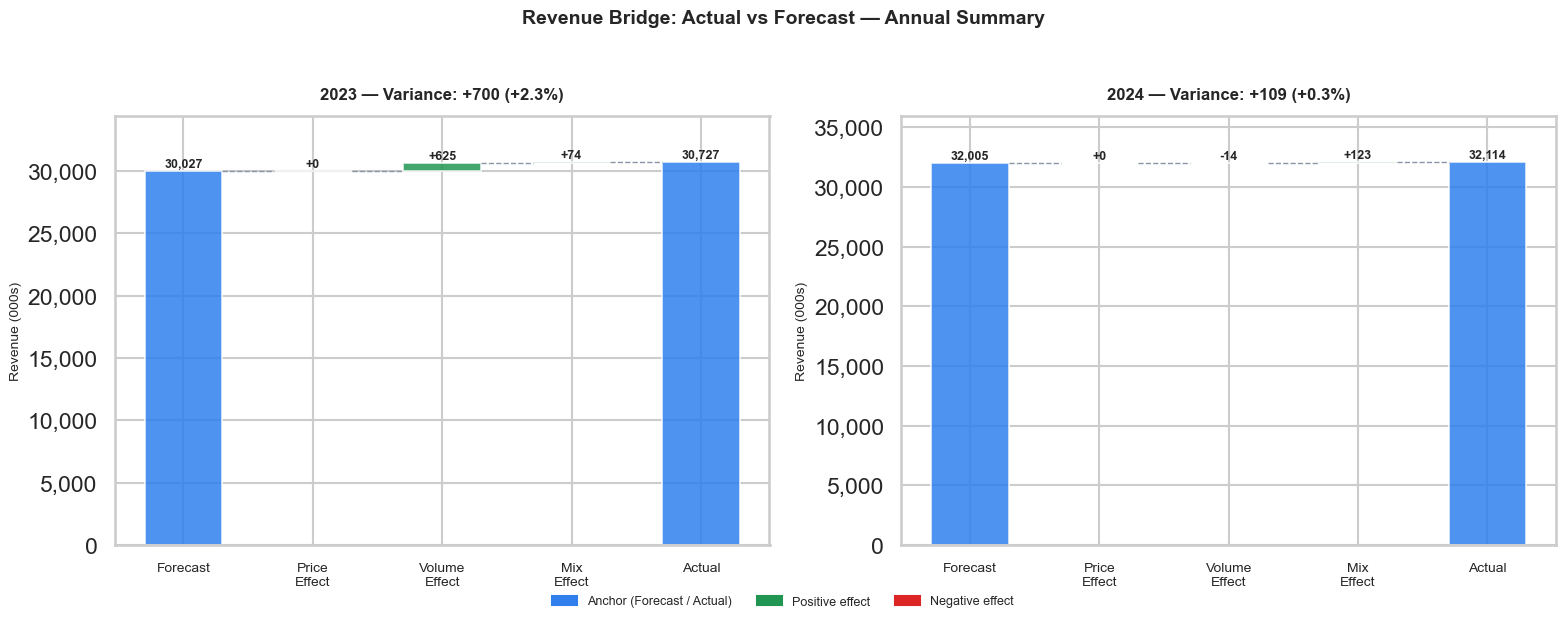

2026-04-15 17:32:10,148 [INFO] Waterfall bridge chart rendered.


In [18]:
def waterfall_bridge(b: dict, title: str, ax: plt.Axes) -> None:
    """Render a 5-bar waterfall: Forecast → Price → Volume → Mix → Actual."""
    labels  = ['Forecast', 'Price\nEffect', 'Volume\nEffect', 'Mix\nEffect', 'Actual']
    effects = [b['Price_eff'], b['Vol_eff'], b['Mix_eff']]

    running = b['Rev_fcst']
    bottoms = [0, running, running + effects[0], running + effects[0] + effects[1]]
    heights = [b['Rev_fcst']] + effects + [b['Rev_act']]
    colors  = [BLUE] + [GREEN if v >= 0 else RED for v in effects] + [BLUE]

    bars = []
    for i, (lbl, h, bot, col) in enumerate(zip(labels, heights, bottoms + [0], colors)):
        if i == 0 or i == 4:  # anchor bars
            bar = ax.bar(i, h, color=col, alpha=0.85, width=0.6, edgecolor='white', linewidth=1.2)
        else:  # floating bars
            bar = ax.bar(i, abs(h), bottom=min(bot, bot + h), 
                         color=col, alpha=0.85, width=0.6, edgecolor='white', linewidth=1.2)
        bars.append(bar)
        # Connector line
        if i < 4:
            next_bot = (bot + h) if i > 0 else h
            ax.plot([i + 0.3, i + 0.7], [next_bot, next_bot], color=GREY, lw=1, ls='--')

    # Labels
    for i, (lbl, h) in enumerate(zip(labels, heights)):
        val = h
        prefix = '+' if (i not in [0, 4] and h >= 0) else ''
        ax.text(i, max(bottoms[i] if i < 4 else 0, 0) + abs(h) + 50,
                f'{prefix}{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Revenue (000s)', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_ylim(0, max(b['Rev_act'], b['Rev_fcst']) * 1.12)


# 2024 bridge uses SQL scenario 3 price-volume detail.
b24_agg = b24_total

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Revenue Bridge: Actual vs Forecast — Annual Summary', fontsize=14, fontweight='bold', y=1.01)

waterfall_bridge(b23_total, f"2023 — Variance: {b23_total['Variance']:+,.0f} ({b23_total['Var_pct']:+.1f}%)", axes[0])
waterfall_bridge(b24_agg,   f"2024 — Variance: {b24_agg['Variance']:+,.0f} ({b24_agg['Var_pct']:+.1f}%)",   axes[1])

# Legend
legend_patches = [mpatches.Patch(color=BLUE, label='Anchor (Forecast / Actual)'),
                  mpatches.Patch(color=GREEN, label='Positive effect'),
                  mpatches.Patch(color=RED,   label='Negative effect')]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, frameon=False, fontsize=9)
plt.tight_layout()
plt.show()
log.info('Waterfall bridge chart rendered.')

### 8 — Monthly Revenue Tracker

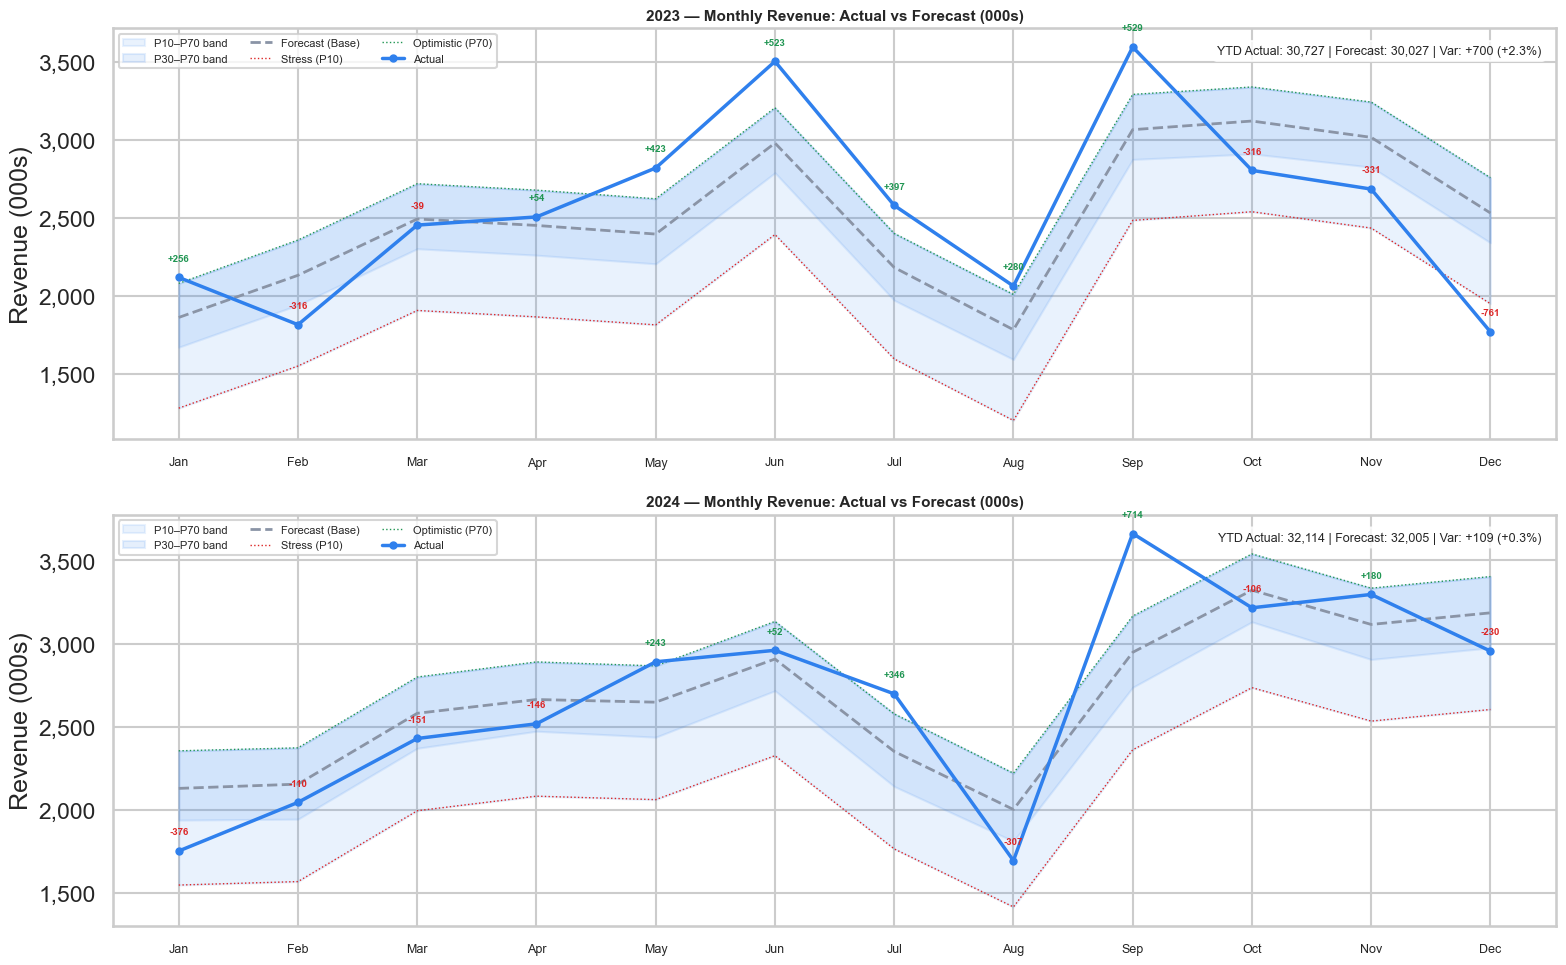

In [19]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)
MONTHS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for ax, yr in zip(axes, [2023, 2024]):
    mb = monthly_bridge[monthly_bridge['Year'] == yr].copy()
    x  = range(len(mb))

    # Scenario band
    ax.fill_between(x, mb['P10'], mb['P70'], color=BLUE, alpha=0.10, label='P10–P70 band')
    ax.fill_between(x, mb['P30'], mb['P70'], color=BLUE, alpha=0.12, label='P30–P70 band')

    ax.plot(x, mb['Rev_fcst'], color=GREY,  lw=2, ls='--', label='Forecast (Base)')
    ax.plot(x, mb['P10'],      color=RED,   lw=1, ls=':',  label='Stress (P10)')
    ax.plot(x, mb['P70'],      color=GREEN, lw=1, ls=':',  label='Optimistic (P70)')
    ax.plot(x, mb['Rev_act'],  color=BLUE,  lw=2.5, marker='o', ms=5, label='Actual')

    # Variance annotations
    for i, row in mb.reset_index().iterrows():
        clr = GREEN if row['Var'] >= 0 else RED
        ax.annotate(f"{row['Var']:+.0f}", (i, row['Rev_act']),
                    xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=7, color=clr, fontweight='bold')

    ax.set_xticks(list(x))
    ax.set_xticklabels(MONTHS[:len(mb)], fontsize=9)
    ax.set_title(f'{yr} — Monthly Revenue: Actual vs Forecast (000s)',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Revenue (000s)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=8, loc='upper left', ncol=3, framealpha=0.8)

    # Cumulative total annotation
    cum_act  = mb['Rev_act'].sum()
    cum_fcst = mb['Rev_fcst'].sum()
    ax.text(0.99, 0.96,
            f"YTD Actual: {cum_act:,.0f} | Forecast: {cum_fcst:,.0f} | Var: {cum_act-cum_fcst:+,.0f} ({(cum_act/cum_fcst-1)*100:+.1f}%)",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

plt.tight_layout()
plt.show()

### 9 — Channel Variance Analysis

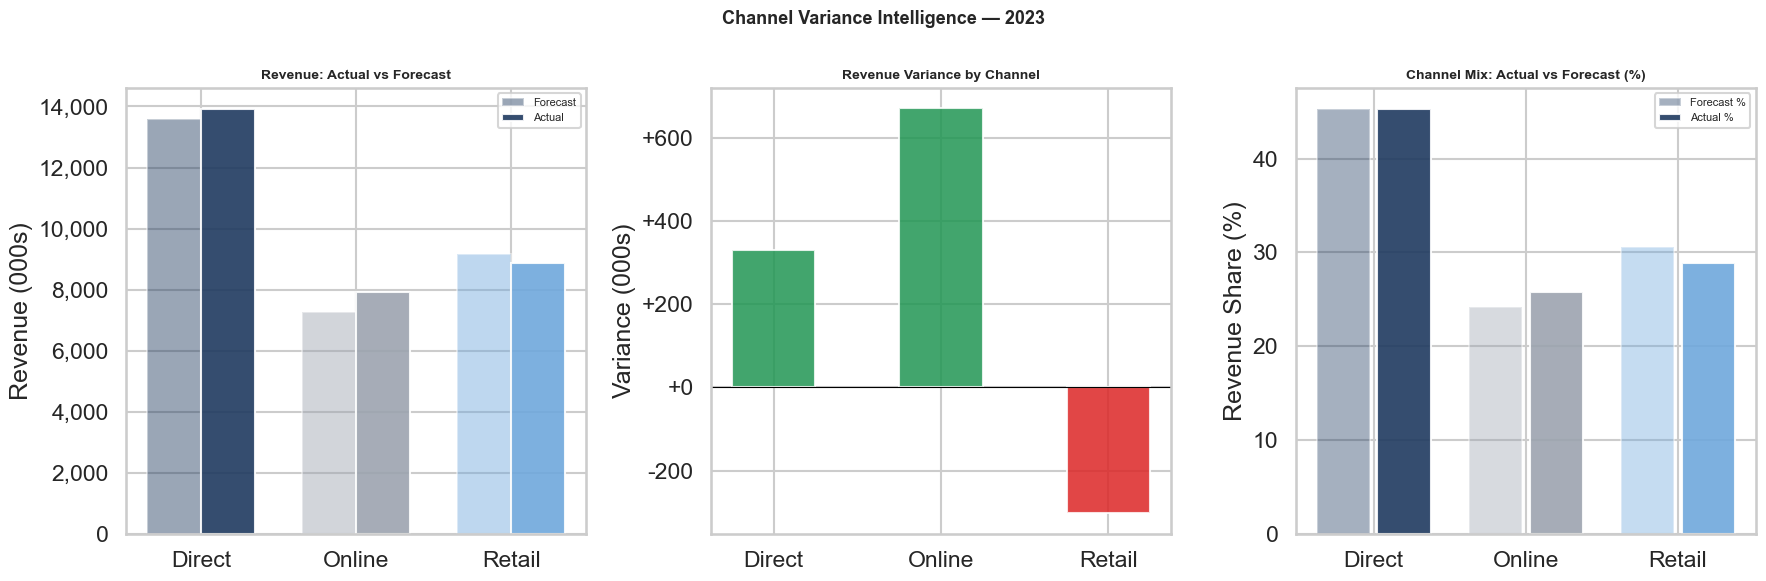


=== Channel Bridge Summary 2023 ===
        Forecast    Actual  Variance  Var%  Volume Eff.  Mix Eff.
Label                                                            
Direct 13,587.40 13,917.80    330.40  2.40       253.50     76.90
Online  7,263.70  7,935.30    671.70  9.20       594.30     77.40
Retail  9,176.40  8,873.80   -302.50 -3.30      -223.70    -78.90


In [20]:
# ── Channel bridge metrics ──────────────────────────────────────────────────
channel_bridges = []
for ch in ['Direct', 'Online', 'Retail']:
    bch = compute_bridge(bridge_23[bridge_23['Channel'] == ch], ch)
    channel_bridges.append(bch)

ch_df = pd.DataFrame(channel_bridges).set_index('Label')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Channel Variance Intelligence — 2023', fontsize=13, fontweight='bold')

# ── Plot 1: Revenue actual vs forecast by channel ──────────────────────────
ax = axes[0]
channels = ch_df.index.tolist()
x = np.arange(len(channels))
w = 0.35
bars_f = ax.bar(x - w/2, ch_df['Rev_fcst'],  width=w, color=[CH_COLORS[c] for c in channels],
                alpha=0.45, label='Forecast', edgecolor='white')
bars_a = ax.bar(x + w/2, ch_df['Rev_act'],   width=w, color=[CH_COLORS[c] for c in channels],
                alpha=0.90, label='Actual',   edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(channels)
ax.set_title('Revenue: Actual vs Forecast', fontsize=10, fontweight='bold')
ax.set_ylabel('Revenue (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=8)

# ── Plot 2: Variance waterfall by channel ──────────────────────────────────
ax = axes[1]
vars_ = ch_df['Variance'].values
colors = [GREEN if v >= 0 else RED for v in vars_]
bars = ax.bar(channels, vars_, color=colors, alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(0, color='black', lw=0.8)

ax.set_title('Revenue Variance by Channel', fontsize=10, fontweight='bold')
ax.set_ylabel('Variance (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))

# ── Plot 3: Channel mix — Actual vs Forecast (donut) ──────────────────────
ax = axes[2]
mix_act  = ch_df['Rev_act']  / ch_df['Rev_act'].sum()  * 100
mix_fcst = ch_df['Rev_fcst'] / ch_df['Rev_fcst'].sum() * 100
x_pos = np.arange(len(channels))
ax.bar(x_pos - 0.2, mix_fcst, 0.35, label='Forecast %',
       color=[CH_COLORS[c] for c in channels], alpha=0.4, edgecolor='white')
ax.bar(x_pos + 0.2, mix_act,  0.35, label='Actual %',
       color=[CH_COLORS[c] for c in channels], alpha=0.9, edgecolor='white')

ax.set_xticks(x_pos); ax.set_xticklabels(channels)
ax.set_title('Channel Mix: Actual vs Forecast (%)', fontsize=10, fontweight='bold')
ax.set_ylabel('Revenue Share (%)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary table
print('\n=== Channel Bridge Summary 2023 ===')
summary_ch = ch_df[['Rev_fcst','Rev_act','Variance','Var_pct','Vol_eff','Mix_eff']].round(1)
summary_ch.columns = ['Forecast','Actual','Variance','Var%','Volume Eff.','Mix Eff.']
print(summary_ch.to_string())

### 10 — Product Variance Analysis

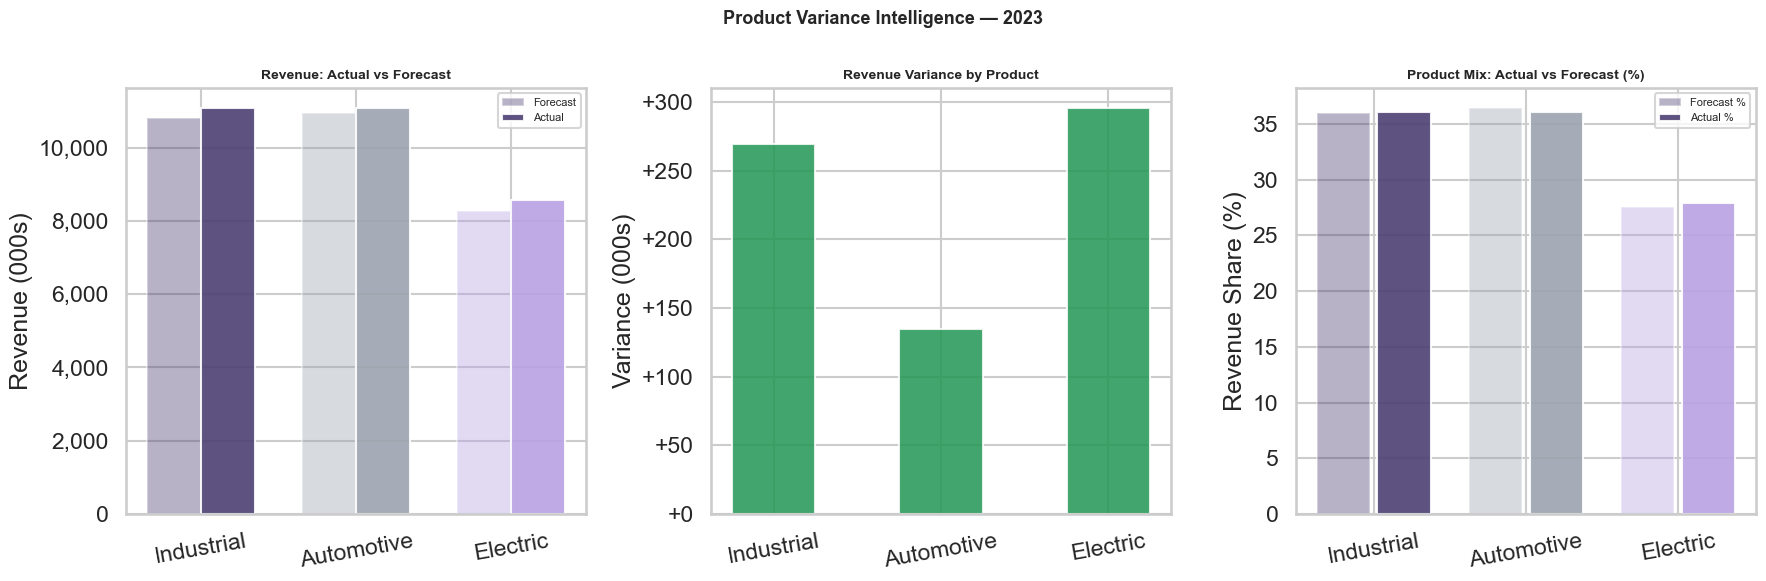


=== Product Bridge Summary 2023 ===
            Forecast    Actual  Variance  Var%  Volume Eff.  Mix Eff.
Label                                                                
Industrial 10,814.70 11,084.00    269.30  2.50       290.50    -21.20
Automotive 10,939.70 11,074.40    134.60  1.20       139.90     -5.20
Electric    8,272.90  8,568.50    295.60  3.60       313.60    -18.10


In [21]:
# ── Product bridge metrics ──────────────────────────────────────────────────
product_bridges = []
for pr in ['Industrial', 'Automotive', 'Electric']:
    bpr = compute_bridge(bridge_23[bridge_23['Product'] == pr], pr)
    product_bridges.append(bpr)

pr_df = pd.DataFrame(product_bridges).set_index('Label')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Product Variance Intelligence — 2023', fontsize=13, fontweight='bold')

products = pr_df.index.tolist()
x = np.arange(len(products))
w = 0.35

# Revenue actual vs forecast
ax = axes[0]
ax.bar(x - w/2, pr_df['Rev_fcst'], width=w, color=[PR_COLORS[p] for p in products],
       alpha=0.4, label='Forecast', edgecolor='white')
bars_a = ax.bar(x + w/2, pr_df['Rev_act'], width=w, color=[PR_COLORS[p] for p in products],
                alpha=0.9, label='Actual', edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(products, rotation=10)
ax.set_title('Revenue: Actual vs Forecast', fontsize=10, fontweight='bold')
ax.set_ylabel('Revenue (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=8)

# Variance bar
ax = axes[1]
vars_ = pr_df['Variance'].values
bars = ax.bar(products, vars_, color=[GREEN if v >= 0 else RED for v in vars_],
              alpha=0.85, edgecolor='white', width=0.5)
ax.axhline(0, color='black', lw=0.8)

ax.set_title('Revenue Variance by Product', fontsize=10, fontweight='bold')
ax.set_ylabel('Variance (000s)')
ax.set_xticklabels(products, rotation=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))

# Product mix shift
ax = axes[2]
mix_act  = pr_df['Rev_act']  / pr_df['Rev_act'].sum()  * 100
mix_fcst = pr_df['Rev_fcst'] / pr_df['Rev_fcst'].sum() * 100
x_pos = np.arange(len(products))
ax.bar(x_pos - 0.2, mix_fcst, 0.35, label='Forecast %',
       color=[PR_COLORS[p] for p in products], alpha=0.4, edgecolor='white')
ax.bar(x_pos + 0.2, mix_act,  0.35, label='Actual %',
       color=[PR_COLORS[p] for p in products], alpha=0.9, edgecolor='white')

ax.set_xticks(x_pos); ax.set_xticklabels(products, rotation=10)
ax.set_title('Product Mix: Actual vs Forecast (%)', fontsize=10, fontweight='bold')
ax.set_ylabel('Revenue Share (%)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

summary_pr = pr_df[['Rev_fcst','Rev_act','Variance','Var_pct','Vol_eff','Mix_eff']].round(1)
summary_pr.columns = ['Forecast','Actual','Variance','Var%','Volume Eff.','Mix Eff.']
print('\n=== Product Bridge Summary 2023 ===')
print(summary_pr.to_string())

### 11 — Mix Effect Deep Dive

Mix Effect = impact of structural shifts in channel and product composition on revenue, independent of total volume changes.

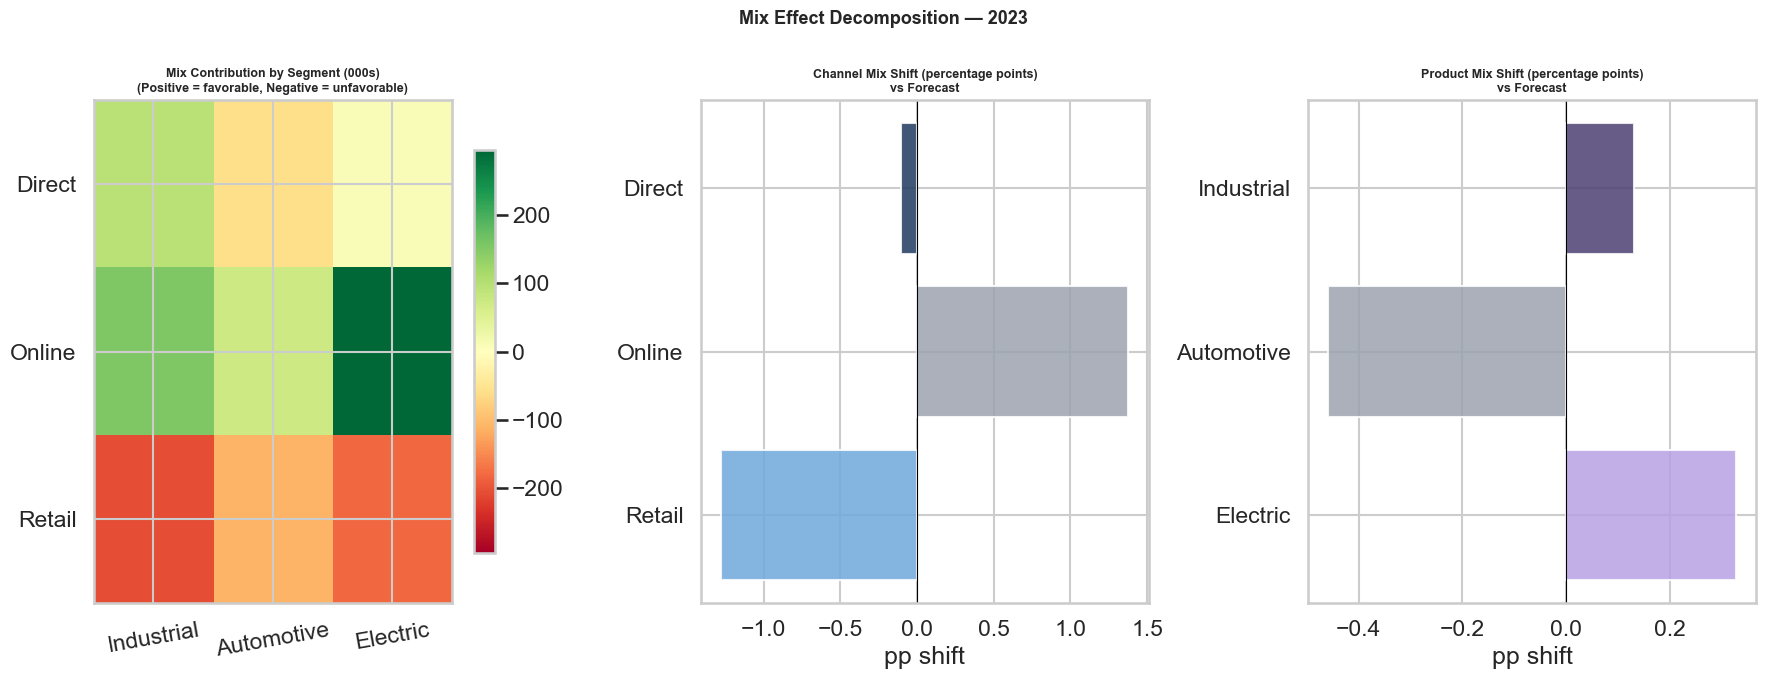

In [22]:
# ── Segment-level mix decomposition ────────────────────────────────────────
seg_df = bridge_23.groupby(['Channel', 'Product']).apply(
    lambda d: pd.Series({
        'Rev_act': d['Rev_act'].sum(),
        'Rev_fcst': d['Rev_fcst'].sum(),
        'Units_act': d['Units_act'].sum(),
        'Units_fcst': d['Units_fcst'].sum(),
        'Price_fcst': (d['Price_fcst'] * d['Units_fcst']).sum() / d['Units_fcst'].sum(),
    })
).reset_index()

# Fixed display order
channel_order = ['Direct', 'Online', 'Retail']
product_order = ['Industrial', 'Automotive', 'Electric']

seg_df['Channel'] = pd.Categorical(
    seg_df['Channel'],
    categories=channel_order,
    ordered=True
)

seg_df['Product'] = pd.Categorical(
    seg_df['Product'],
    categories=product_order,
    ordered=True
)

seg_df = seg_df.sort_values(['Channel', 'Product'])

# Total units actual and forecast
Q_act = seg_df['Units_act'].sum()
Q_fcst = seg_df['Units_fcst'].sum()

# Share of units: actual vs forecast
seg_df['Share_act'] = seg_df['Units_act'] / Q_act
seg_df['Share_fcst'] = seg_df['Units_fcst'] / Q_fcst
seg_df['Share_shift'] = seg_df['Share_act'] - seg_df['Share_fcst']

# Mix effect per segment: (Share_shift) × Total_Q_act × P_fcst / 1000
seg_df['Mix_contrib'] = seg_df['Share_shift'] * Q_act * seg_df['Price_fcst'] / 1_000
seg_df['Segment'] = seg_df['Channel'].astype(str) + ' / ' + seg_df['Product'].astype(str)

# ── Channel mix summary ─────────────────────────────────────────────────────
ch_mix = bridge_23.groupby('Channel').apply(
    lambda d: pd.Series({
        'Share_act': d['Units_act'].sum() / bridge_23['Units_act'].sum() * 100,
        'Share_fcst': d['Units_fcst'].sum() / bridge_23['Units_fcst'].sum() * 100,
        'Avg_P_fcst': (d['Price_fcst'] * d['Units_fcst']).sum() / d['Units_fcst'].sum()
    })
).reset_index()

ch_mix['shift_pp'] = ch_mix['Share_act'] - ch_mix['Share_fcst']

ch_mix['Channel'] = pd.Categorical(
    ch_mix['Channel'],
    categories=channel_order,
    ordered=True
)

ch_mix = ch_mix.sort_values('Channel')

# ── Product mix summary ─────────────────────────────────────────────────────
pr_mix = bridge_23.groupby('Product').apply(
    lambda d: pd.Series({
        'Share_act': d['Units_act'].sum() / bridge_23['Units_act'].sum() * 100,
        'Share_fcst': d['Units_fcst'].sum() / bridge_23['Units_fcst'].sum() * 100,
        'Avg_P_fcst': (d['Price_fcst'] * d['Units_fcst']).sum() / d['Units_fcst'].sum()
    })
).reset_index()

pr_mix['shift_pp'] = pr_mix['Share_act'] - pr_mix['Share_fcst']

pr_mix['Product'] = pd.Categorical(
    pr_mix['Product'],
    categories=product_order,
    ordered=True
)

pr_mix = pr_mix.sort_values('Product')

# ── Visualization ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Mix Effect Decomposition — 2023', fontsize=13, fontweight='bold')

# Segment mix contribution heatmap
ax = axes[0]

seg_pivot = seg_df.pivot(
    index='Channel',
    columns='Product',
    values='Mix_contrib'
)

seg_pivot = seg_pivot.loc[channel_order, product_order]

im = ax.imshow(
    seg_pivot.values,
    cmap='RdYlGn',
    aspect='auto',
    vmin=-abs(seg_pivot.values).max(),
    vmax=abs(seg_pivot.values).max()
)

ax.set_xticks(range(len(seg_pivot.columns)))
ax.set_xticklabels(seg_pivot.columns, rotation=10)

ax.set_yticks(range(len(seg_pivot.index)))
ax.set_yticklabels(seg_pivot.index)

plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_title(
    'Mix Contribution by Segment (000s)\n(Positive = favorable, Negative = unfavorable)',
    fontsize=9,
    fontweight='bold'
)

# Channel mix shift
ax = axes[1]

ch_colors_list = [CH_COLORS[c] for c in ch_mix['Channel'].astype(str)]

bars = ax.barh(
    ch_mix['Channel'].astype(str),
    ch_mix['shift_pp'],
    color=ch_colors_list,
    alpha=0.85,
    edgecolor='white'
)

ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.8)

ax.set_title(
    'Channel Mix Shift (percentage points)\nvs Forecast',
    fontsize=9,
    fontweight='bold'
)

ax.set_xlabel('pp shift')

# Product mix shift
ax = axes[2]

pr_colors_list = [PR_COLORS[p] for p in pr_mix['Product'].astype(str)]

bars = ax.barh(
    pr_mix['Product'].astype(str),
    pr_mix['shift_pp'],
    color=pr_colors_list,
    alpha=0.85,
    edgecolor='white'
)

ax.invert_yaxis()
ax.axvline(0, color='black', lw=0.8)

ax.set_title(
    'Product Mix Shift (percentage points)\nvs Forecast',
    fontsize=9,
    fontweight='bold'
)

ax.set_xlabel('pp shift')

plt.tight_layout()
plt.show()


### 12 — Price Trajectory & Realization Analysis

Although the Price Effect = 0 in both years (prices are set as annual planning assumptions and held to plan), the YoY price evolution carries valuable FP&A signal.

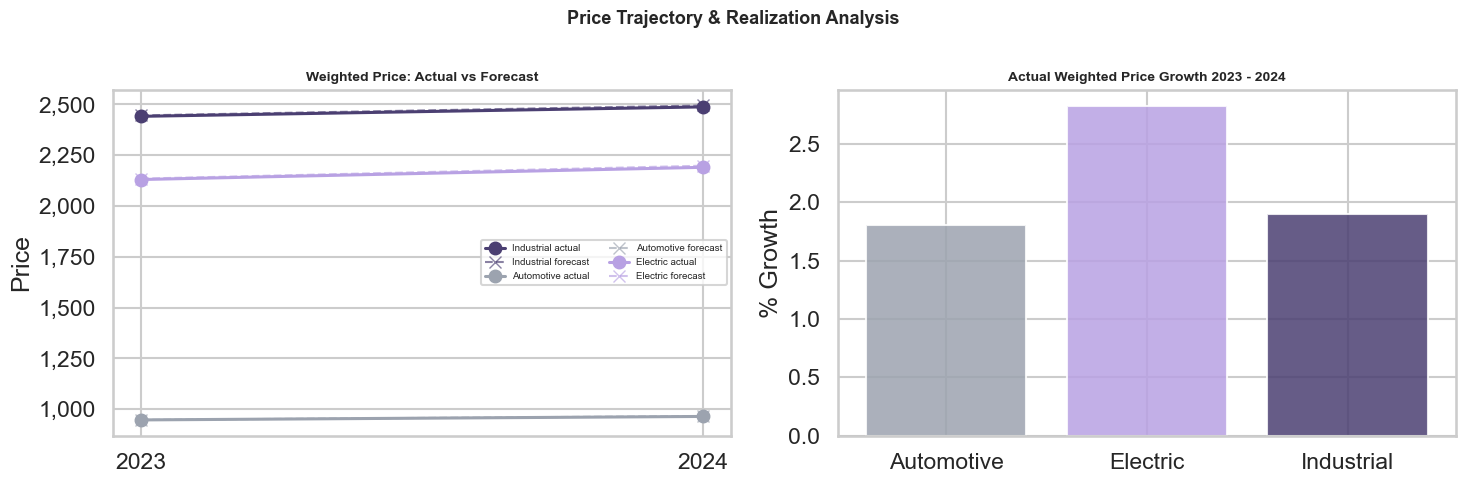

=== Price YoY Summary ===
Year           2023     2024  YoY Price Growth %
Product                                         
Automotive   946.77   963.89                1.81
Electric   2,129.88 2,189.98                2.82
Industrial 2,440.88 2,487.32                1.90


In [23]:
# Price evolution: weighted average actual price by product and channel from SQL fact_price_volume.
price_product = (
    bridge_all
    .groupby(['Year', 'Product'])
    .apply(lambda d: pd.Series({
        'Actual Weighted Price': (d['Price_act'] * d['Units_act']).sum() / d['Units_act'].sum(),
        'Forecast Weighted Price': (d['Price_fcst'] * d['Units_fcst']).sum() / d['Units_fcst'].sum(),
        'Actual Units': d['Units_act'].sum(),
        'Forecast Units': d['Units_fcst'].sum(),
        'Actual Revenue': d['Rev_act'].sum(),
        'Forecast Revenue': d['Rev_fcst'].sum(),
    }))
    .reset_index()
)

price_yoy = price_product.pivot(index='Product', columns='Year', values='Actual Weighted Price')
price_yoy['YoY Price Growth %'] = (price_yoy[2024] / price_yoy[2023] - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Price Trajectory & Realization Analysis', fontsize=13, fontweight='bold')

ax = axes[0]
for product in ['Industrial', 'Automotive', 'Electric']:
    sub = price_product[price_product['Product'] == product]
    ax.plot(sub['Year'], sub['Actual Weighted Price'], marker='o', linewidth=2.2,
            color=PR_COLORS[product], label=f'{product} actual')
    ax.plot(sub['Year'], sub['Forecast Weighted Price'], marker='x', linestyle='--', linewidth=1.5,
            color=PR_COLORS[product], alpha=0.65, label=f'{product} forecast')
ax.set_xticks([2023, 2024])
ax.set_title('Weighted Price: Actual vs Forecast', fontsize=10, fontweight='bold')
ax.set_ylabel('Price')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=7, ncol=2)

ax = axes[1]
bars = ax.bar(price_yoy.index, price_yoy['YoY Price Growth %'],
              color=[PR_COLORS[p] for p in price_yoy.index], alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)

ax.set_title('Actual Weighted Price Growth 2023 - 2024', fontsize=10, fontweight='bold')
ax.set_ylabel('% Growth')

plt.tight_layout()
plt.show()

print('=== Price YoY Summary ===')
print(price_yoy.round(2).to_string())

### 13 — Gross Margin Bridge (Revenue → Gross Profit)

Using forecast COGS (ScenarioKey=3) and actual revenue to compute the Gross Margin bridge.

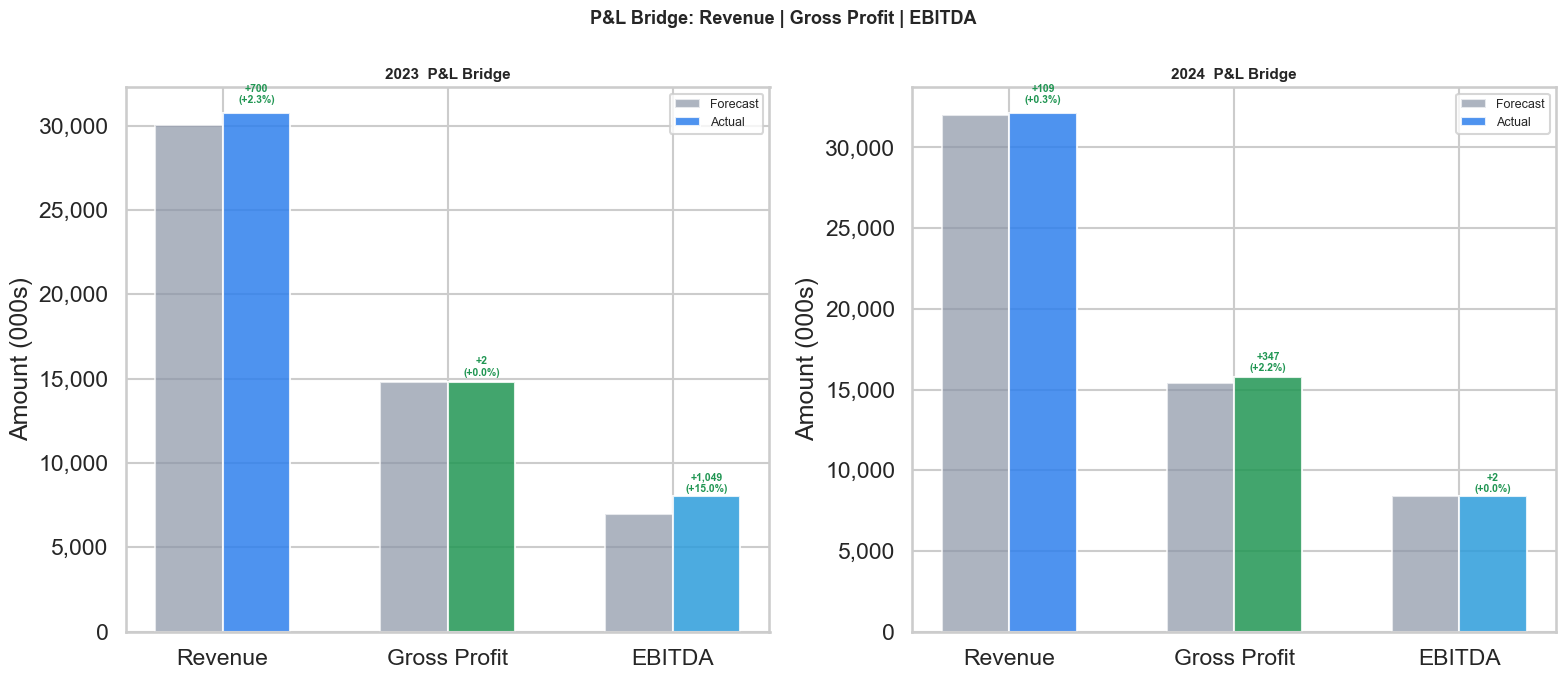


=== Margin Summary ===
       Rev (A)    GP (A)  EBITDA (A)   NI (A)  GM% (A)  EBITDA% (A)   Rev (F)    GP (F)  EBITDA (F)   NI (F)  GM% (F)  EBITDA% (F)
2023 30,726.90 14,808.30    8,048.40 4,286.10    48.20        26.20 30,027.30 14,806.50    6,999.40 3,547.00    49.30        23.30
2024 32,114.30 15,771.30    8,385.00 4,415.10    49.10        26.10 32,005.00 15,424.30    8,383.20 4,412.90    48.20        26.20


In [24]:
# Official P&L bridge from SQL reporting views.
years = [2023, 2024]
pl_a = pl_annual_actual.set_index('year')
pl_f = pl_annual_fcst.set_index('year')

pl_bridge = pd.DataFrame(index=years)
pl_bridge['Rev_act'] = pl_a.loc[years, 'revenue'].values
pl_bridge['Rev_fcst'] = pl_f.loc[years, 'revenue'].values
pl_bridge['COGS_act'] = pl_a.loc[years, 'cogs'].values
pl_bridge['COGS_fcst'] = pl_f.loc[years, 'cogs'].values
pl_bridge['GP_act'] = pl_a.loc[years, 'gross_profit'].values
pl_bridge['GP_fcst'] = pl_f.loc[years, 'gross_profit'].values
pl_bridge['OPEX_act'] = pl_a.loc[years, 'opex'].values
pl_bridge['OPEX_fcst'] = pl_f.loc[years, 'opex'].values
pl_bridge['EBITDA_act'] = pl_a.loc[years, 'ebitda'].values
pl_bridge['EBITDA_fcst'] = pl_f.loc[years, 'ebitda'].values
pl_bridge['NetIncome_act'] = pl_a.loc[years, 'net_income'].values
pl_bridge['NetIncome_fcst'] = pl_f.loc[years, 'net_income'].values

pl_bridge['Rev_var'] = pl_bridge['Rev_act'] - pl_bridge['Rev_fcst']
pl_bridge['GP_var'] = pl_bridge['GP_act'] - pl_bridge['GP_fcst']
pl_bridge['OPEX_var'] = pl_bridge['OPEX_act'] - pl_bridge['OPEX_fcst']
pl_bridge['EBITDA_var'] = pl_bridge['EBITDA_act'] - pl_bridge['EBITDA_fcst']
pl_bridge['NetIncome_var'] = pl_bridge['NetIncome_act'] - pl_bridge['NetIncome_fcst']
pl_bridge['GM_pct_act'] = pl_bridge['GP_act'] / pl_bridge['Rev_act'] * 100
pl_bridge['GM_pct_fcst'] = pl_bridge['GP_fcst'] / pl_bridge['Rev_fcst'] * 100
pl_bridge['EBITDA_pct_act'] = pl_bridge['EBITDA_act'] / pl_bridge['Rev_act'] * 100
pl_bridge['EBITDA_pct_fcst'] = pl_bridge['EBITDA_fcst'] / pl_bridge['Rev_fcst'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('P&L Bridge: Revenue | Gross Profit | EBITDA', fontsize=13, fontweight='bold')
metrics = ['Revenue', 'Gross Profit', 'EBITDA']

for ax, yr in zip(axes, years):
    act_v = [pl_bridge.loc[yr, 'Rev_act'], pl_bridge.loc[yr, 'GP_act'], pl_bridge.loc[yr, 'EBITDA_act']]
    fcst_v = [pl_bridge.loc[yr, 'Rev_fcst'], pl_bridge.loc[yr, 'GP_fcst'], pl_bridge.loc[yr, 'EBITDA_fcst']]
    x = np.arange(3)
    w = 0.3
    ax.bar(x - w/2, fcst_v, width=w, color=[GREY, GREY, GREY], alpha=0.7, label='Forecast', edgecolor='white')
    ax.bar(x + w/2, act_v, width=w, color=[BLUE, GREEN, TEAL], alpha=0.85, label='Actual', edgecolor='white')
    for i, (av, fv) in enumerate(zip(act_v, fcst_v)):
        var = av - fv
        pct = var / fv * 100
        ax.text(i + w/2, av + max(abs(av), abs(fv)) * 0.015,
                f'{var:+,.0f}\n({pct:+.1f}%)',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold',
                color=GREEN if var >= 0 else RED)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.set_title(f'{yr}  P&L Bridge', fontsize=11, fontweight='bold')
    ax.set_ylabel('Amount (000s)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\n=== Margin Summary ===')
margin_tbl = pl_bridge[[
    'Rev_act', 'GP_act', 'EBITDA_act', 'NetIncome_act', 'GM_pct_act', 'EBITDA_pct_act',
    'Rev_fcst', 'GP_fcst', 'EBITDA_fcst', 'NetIncome_fcst', 'GM_pct_fcst', 'EBITDA_pct_fcst'
]].round(1)
margin_tbl.columns = [
    'Rev (A)', 'GP (A)', 'EBITDA (A)', 'NI (A)', 'GM% (A)', 'EBITDA% (A)',
    'Rev (F)', 'GP (F)', 'EBITDA (F)', 'NI (F)', 'GM% (F)', 'EBITDA% (F)'
]
print(margin_tbl.to_string())

### 13.1 — SQL Reconciliation Controls

In [25]:
pv_recon = bridge_all.groupby('Year').agg(
    Rev_act_pv=('Rev_act', 'sum'),
    Rev_fcst_pv=('Rev_fcst', 'sum')
).join(pl_bridge[['Rev_act', 'Rev_fcst']])
pv_recon['Actual Diff'] = pv_recon['Rev_act_pv'] - pv_recon['Rev_act']
pv_recon['Forecast Diff'] = pv_recon['Rev_fcst_pv'] - pv_recon['Rev_fcst']
pv_recon['Bridge Check'] = [b23_total['Check'], b24_total['Check']]
print('=== Reconciliation Controls ===')
print(pv_recon.round(6).to_string())

=== Reconciliation Controls ===
      Rev_act_pv  Rev_fcst_pv   Rev_act  Rev_fcst  Actual Diff  Forecast Diff  Bridge Check
Year                                                                                       
2023   30,726.94    30,027.41 30,726.94 30,027.34         0.00           0.07          0.00
2024   32,114.32    32,004.94 32,114.33 32,004.99        -0.01          -0.05          0.00


### 13.2 — Cash Flow Variance (SQL Views)

=== Cash Flow Variance ===
 Year   Metric    Actual  Forecast  Variance  Variance %
 2023      CFO  5,681.92  4,879.96    801.96       16.43
 2023      CFI -3,492.56 -3,492.56      0.00        0.00
 2023      CFF -2,422.27 -1,987.73   -434.54      -21.86
 2023 CASH_END  1,243.54    842.48    401.06       47.60
 2024      CFO  6,276.18  6,131.93    144.25        2.35
 2024      CFI -3,687.23 -3,687.23      0.00        0.00
 2024      CFF -2,704.54 -2,478.20   -226.34       -9.13
 2024 CASH_END  1,127.95  1,113.45     14.50        1.30


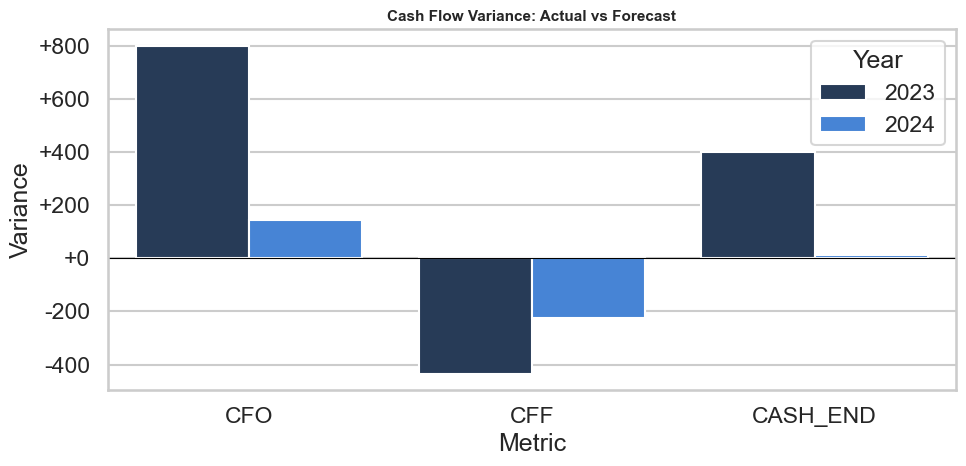

In [26]:
cf_a = cf_annual_actual.set_index('year')
cf_f = cf_annual_fcst.set_index('year')
cf_metrics = ['cfo', 'cfi', 'cff', 'cash_end']
cf_variance = []
for yr in years:
    for metric in cf_metrics:
        actual = cf_a.loc[yr, metric]
        forecast = cf_f.loc[yr, metric]
        var = actual - forecast
        cf_variance.append({'Year': yr, 'Metric': metric.upper(), 'Actual': actual,
                            'Forecast': forecast, 'Variance': var,
                            'Variance %': var / abs(forecast) * 100 if forecast else np.nan})
cf_variance = pd.DataFrame(cf_variance)
print('=== Cash Flow Variance ===')
print(cf_variance.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
plot_cf = cf_variance[cf_variance['Metric'].isin(['CFO', 'CFF', 'CASH_END'])]
sns.barplot(data=plot_cf, x='Metric', y='Variance', hue='Year', ax=ax)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Cash Flow Variance: Actual vs Forecast', fontsize=11, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:+,.0f}'))
plt.tight_layout()
plt.show()

### 13.3 — Balance Sheet & Working Capital Variance (SQL Views)

In [27]:
bs_a = bs_annual_actual.set_index('year')
bs_f = bs_annual_fcst.set_index('year')
bs_metrics = ['cash', 'accountsreceivable', 'inventory', 'accountspayable',
              'revolvingcredit', 'totalassets', 'totalliabilities', 'totalequity', 'equitycheck']
bs_metrics = [m for m in bs_metrics if m in bs_a.columns and m in bs_f.columns]
bs_variance = []
for yr in years:
    for metric in bs_metrics:
        actual = bs_a.loc[yr, metric]
        forecast = bs_f.loc[yr, metric]
        var = actual - forecast
        bs_variance.append({'Year': yr, 'Metric': metric, 'Actual': actual,
                            'Forecast': forecast, 'Variance': var,
                            'Variance %': var / abs(forecast) * 100 if forecast else np.nan})
bs_variance = pd.DataFrame(bs_variance)
wc_variance = bs_variance[bs_variance['Metric'].isin(['accountsreceivable', 'inventory', 'accountspayable', 'cash'])]
print('=== Balance Sheet / Working Capital Variance ===')
print(bs_variance.round(2).to_string(index=False))

=== Balance Sheet / Working Capital Variance ===
 Year             Metric    Actual  Forecast  Variance  Variance %
 2023               cash  1,243.54    842.48    401.06       47.60
 2023 accountsreceivable  6,985.12  6,985.12      0.00        0.00
 2023          inventory  3,661.28  3,653.00      8.28        0.23
 2023    accountspayable  5,093.95  5,022.88     71.07        1.41
 2023    revolvingcredit      0.00      0.00      0.00         NaN
 2023        totalassets 40,959.16 40,583.46    375.70        0.93
 2023   totalliabilities 13,864.87 13,821.79     43.08        0.31
 2023        totalequity 27,094.29 26,761.67    332.62        1.24
 2023        equitycheck      0.00      0.00      0.00         NaN
 2024               cash  1,127.95  1,113.45     14.50        1.30
 2024 accountsreceivable  7,067.20  7,067.20      0.00        0.00
 2024          inventory  3,595.47  3,813.56   -218.09       -5.72
 2024    accountspayable  5,229.78  5,305.82    -76.04       -1.43
 2024    revo

### 13.4 — FP&A Risk Matrix

In [28]:
def risk_label(abs_pct, cuts=(2, 5, 10)):
    if pd.isna(abs_pct): return 'N/A'
    if abs_pct <= cuts[0]: return 'NORMAL'
    if abs_pct <= cuts[1]: return 'WATCH'
    if abs_pct <= cuts[2]: return 'WARNING'
    return 'ALERT'

risk_rows = []
for yr in years:
    rev_risk = abs((pl_bridge.loc[yr, 'Rev_act'] - pl_bridge.loc[yr, 'Rev_fcst']) / pl_bridge.loc[yr, 'Rev_fcst'] * 100)
    ebitda_risk = abs((pl_bridge.loc[yr, 'EBITDA_act'] - pl_bridge.loc[yr, 'EBITDA_fcst']) / pl_bridge.loc[yr, 'EBITDA_fcst'] * 100)
    ni_risk = abs((pl_bridge.loc[yr, 'NetIncome_act'] - pl_bridge.loc[yr, 'NetIncome_fcst']) / pl_bridge.loc[yr, 'NetIncome_fcst'] * 100)
    cfo_risk = abs(cf_variance[(cf_variance['Year'] == yr) & (cf_variance['Metric'] == 'CFO')]['Variance %'].iloc[0])
    cash_risk = abs(cf_variance[(cf_variance['Year'] == yr) & (cf_variance['Metric'] == 'CASH_END')]['Variance %'].iloc[0])
    score = 0.25 * rev_risk + 0.25 * ebitda_risk + 0.20 * ni_risk + 0.20 * cfo_risk + 0.10 * cash_risk
    risk_rows.append({'Year': yr, 'Revenue Risk %': rev_risk, 'EBITDA Risk %': ebitda_risk,
                      'Net Income Risk %': ni_risk, 'CFO Risk %': cfo_risk,
                      'Cash Risk %': cash_risk, 'FP&A Risk Score': score,
                      'Severity': risk_label(score)})
fpna_risk_matrix = pd.DataFrame(risk_rows)
print('=== FP&A Risk Matrix ===')
print(fpna_risk_matrix.round(2).to_string(index=False))

=== FP&A Risk Matrix ===
 Year  Revenue Risk %  EBITDA Risk %  Net Income Risk %  CFO Risk %  Cash Risk %  FP&A Risk Score Severity
 2023            2.33          14.99              20.84       16.43        47.60            16.54    ALERT
 2024            0.34           0.02               0.05        2.35         1.30             0.70   NORMAL


### 14 — Scenario Sensitivity Analysis

Revenue envelope (P10 / P30 / Base / P70) and EBITDA sensitivity under each scenario.

2026-04-15 17:32:13,054 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-15 17:32:13,057 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-15 17:32:13,059 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-15 17:32:13,060 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-15 17:32:13,062 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or 

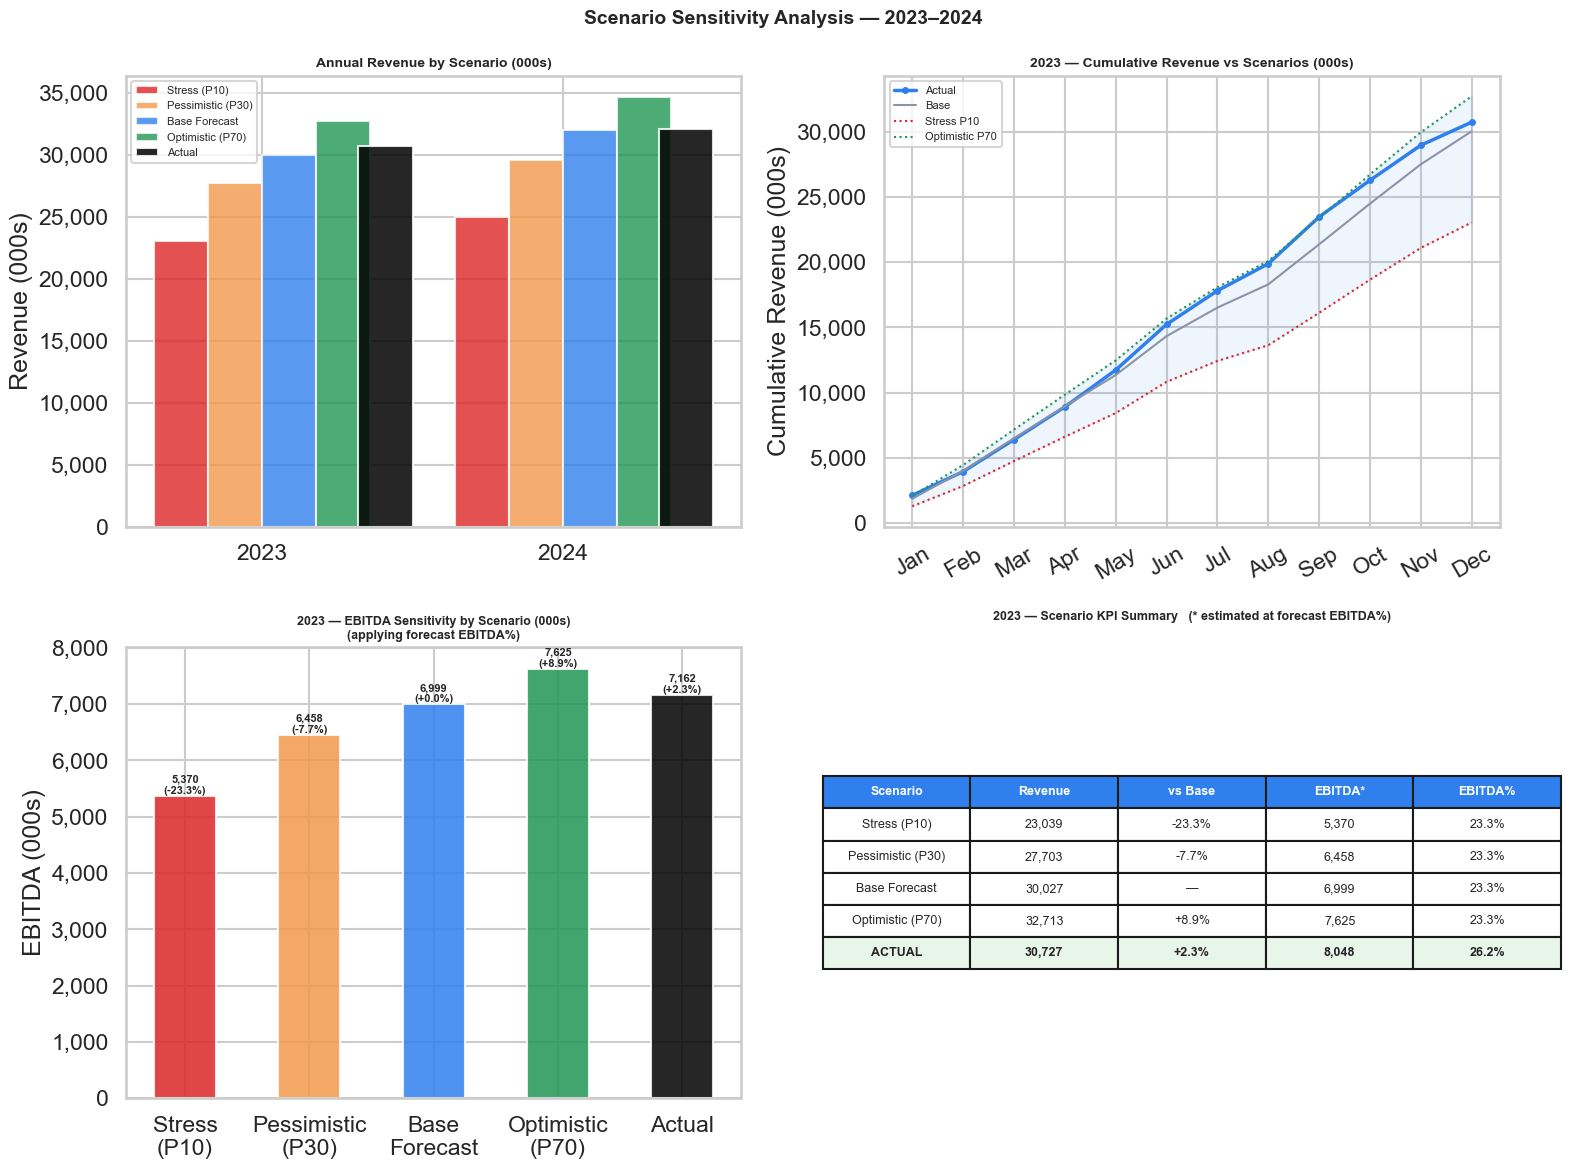

In [29]:
# ── Scenario annual summary ─────────────────────────────────────────────────
sc_annual = monthly_bridge.groupby('Year').agg(
    Rev_act  = ('Rev_act',  'sum'),
    Rev_fcst = ('Rev_fcst', 'sum'),
    P10      = ('P10',      'sum'),
    P30      = ('P30',      'sum'),
    P70      = ('P70',      'sum'),
).round(0)

# EBITDA% assumption from forecast
ebitda_pct_fcst = {yr: pl_bridge.loc[yr, 'EBITDA_pct_fcst'] / 100 for yr in years}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Scenario Sensitivity Analysis — 2023–2024', fontsize=14, fontweight='bold')

# ── Annual revenue fan by scenario ─────────────────────────────────────────
ax = axes[0, 0]
sc_cols = {'P10': ('Stress (P10)', RED), 'P30': ('Pessimistic (P30)', ORANGE),
           'Rev_fcst': ('Base Forecast', BLUE), 'P70': ('Optimistic (P70)', GREEN)}
x = np.arange(2); w = 0.18
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]
for (col, (lbl, clr)), off in zip(sc_cols.items(), offsets):
    ax.bar(x + off, sc_annual[col], width=w, color=clr, alpha=0.80,
           label=lbl, edgecolor='white')
ax.bar(x + 2*w + 0.05, sc_annual['Rev_act'], width=w, color='black', alpha=0.85,
       label='Actual', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels([2023, 2024])
ax.set_title('Annual Revenue by Scenario (000s)', fontsize=10, fontweight='bold')
ax.set_ylabel('Revenue (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=8, loc='upper left')

# ── Monthly cumulative actual vs scenarios (2023) ───────────────────────────
ax = axes[0, 1]
mb23 = monthly_bridge[monthly_bridge['Year'] == 2023].copy()
for col, clr, lbl in [('Rev_act', BLUE, 'Actual'), ('Rev_fcst', GREY, 'Base'),
                       ('P10', RED, 'Stress P10'), ('P70', GREEN, 'Optimistic P70')]:
    cumvals = mb23[col].cumsum().values
    ls = '-' if col in ('Rev_act', 'Rev_fcst') else ':'
    lw = 2.5 if col == 'Rev_act' else 1.5
    ax.plot(MONTHS, cumvals, color=clr, lw=lw, ls=ls, label=lbl, marker='o' if col=='Rev_act' else None, ms=4)
ax.fill_between(MONTHS, mb23['P10'].cumsum(), mb23['P70'].cumsum(), alpha=0.08, color=BLUE)
ax.set_title('2023 — Cumulative Revenue vs Scenarios (000s)', fontsize=10, fontweight='bold')
ax.set_ylabel('Cumulative Revenue (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

# ── EBITDA sensitivity by scenario (2023) ──────────────────────────────────
ax = axes[1, 0]
ebitda_pct = pl_bridge.loc[2023, 'EBITDA_pct_fcst'] / 100
sc_rev_23  = {k: sc_annual.loc[2023, k] for k in ['P10', 'P30', 'Rev_fcst', 'P70', 'Rev_act']}
sc_labels  = ['Stress\n(P10)', 'Pessimistic\n(P30)', 'Base\nForecast', 'Optimistic\n(P70)', 'Actual']
sc_vals    = list(sc_rev_23.values())
sc_ebitda  = [v * ebitda_pct for v in sc_vals]
sc_colors  = [RED, ORANGE, BLUE, GREEN, 'black']

bars = ax.bar(sc_labels, sc_ebitda, color=sc_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, v in zip(bars, sc_ebitda):
    ax.text(bar.get_x() + bar.get_width()/2, v + 30,
            f'{v:,.0f}\n({v/sc_ebitda[2]-1:+.1%})', ha='center', fontsize=8, fontweight='bold')
ax.set_title('2023 — EBITDA Sensitivity by Scenario (000s)\n(applying forecast EBITDA%)',
             fontsize=9, fontweight='bold')
ax.set_ylabel('EBITDA (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

# ── Scenario KPI summary table (2023) ──────────────────────────────────────
ax = axes[1, 1]
ax.axis('off')
sc_table_data = [
    ['Scenario',       'Revenue', 'vs Base', 'EBITDA*', 'EBITDA%'],
    ['Stress (P10)',   f"{sc_rev_23['P10']:,.0f}",     f"{(sc_rev_23['P10']/sc_rev_23['Rev_fcst']-1)*100:+.1f}%",
     f"{sc_rev_23['P10']*ebitda_pct:,.0f}",            f"{ebitda_pct*100:.1f}%"],
    ['Pessimistic (P30)', f"{sc_rev_23['P30']:,.0f}",  f"{(sc_rev_23['P30']/sc_rev_23['Rev_fcst']-1)*100:+.1f}%",
     f"{sc_rev_23['P30']*ebitda_pct:,.0f}",            f"{ebitda_pct*100:.1f}%"],
    ['Base Forecast',  f"{sc_rev_23['Rev_fcst']:,.0f}", '—',
     f"{sc_rev_23['Rev_fcst']*ebitda_pct:,.0f}",       f"{ebitda_pct*100:.1f}%"],
    ['Optimistic (P70)', f"{sc_rev_23['P70']:,.0f}",   f"{(sc_rev_23['P70']/sc_rev_23['Rev_fcst']-1)*100:+.1f}%",
     f"{sc_rev_23['P70']*ebitda_pct:,.0f}",            f"{ebitda_pct*100:.1f}%"],
    ['ACTUAL',         f"{sc_rev_23['Rev_act']:,.0f}", f"{(sc_rev_23['Rev_act']/sc_rev_23['Rev_fcst']-1)*100:+.1f}%",
     f"{sc_rev_23['Rev_act']*pl_bridge.loc[2023,'EBITDA_pct_act']/100:,.0f}",
     f"{pl_bridge.loc[2023,'EBITDA_pct_act']:.1f}%"],
]
tbl = ax.table(cellText=sc_table_data[1:], colLabels=sc_table_data[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.8)
# Color header
for j in range(5):
    tbl[0, j].set_facecolor(BLUE)
    tbl[0, j].set_text_props(color='white', fontweight='bold')
# Color actual row
for j in range(5):
    tbl[5, j].set_facecolor('#E8F5E9')
    tbl[5, j].set_text_props(fontweight='bold')
ax.set_title('2023 — Scenario KPI Summary   (* estimated at forecast EBITDA%)',
             fontsize=9, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

### 15 — Variance Heatmap (Monthly × Year)

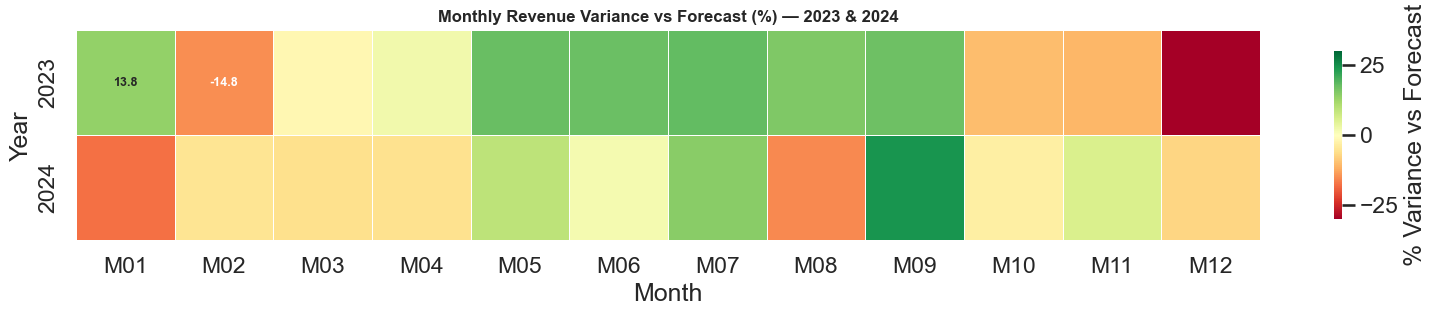

In [30]:
# ── Variance calendar heatmap ───────────────────────────────────────────────
heatmap_data = monthly_bridge.pivot(index='Year', columns='Month', values='Var_pct')
heatmap_data.columns = [f'M{m:02d}' for m in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(16, 3.5))
vmax = max(abs(heatmap_data.values.flatten()))
sns.heatmap(heatmap_data, ax=ax, cmap='RdYlGn', center=0,
            vmin=-vmax, vmax=vmax,
            annot=True, fmt='.1f', annot_kws={'size': 9, 'weight': 'bold'},
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '% Variance vs Forecast', 'shrink': 0.8})
ax.set_title('Monthly Revenue Variance vs Forecast (%) — 2023 & 2024',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

### 16 — YoY Performance: 2023 → 2024

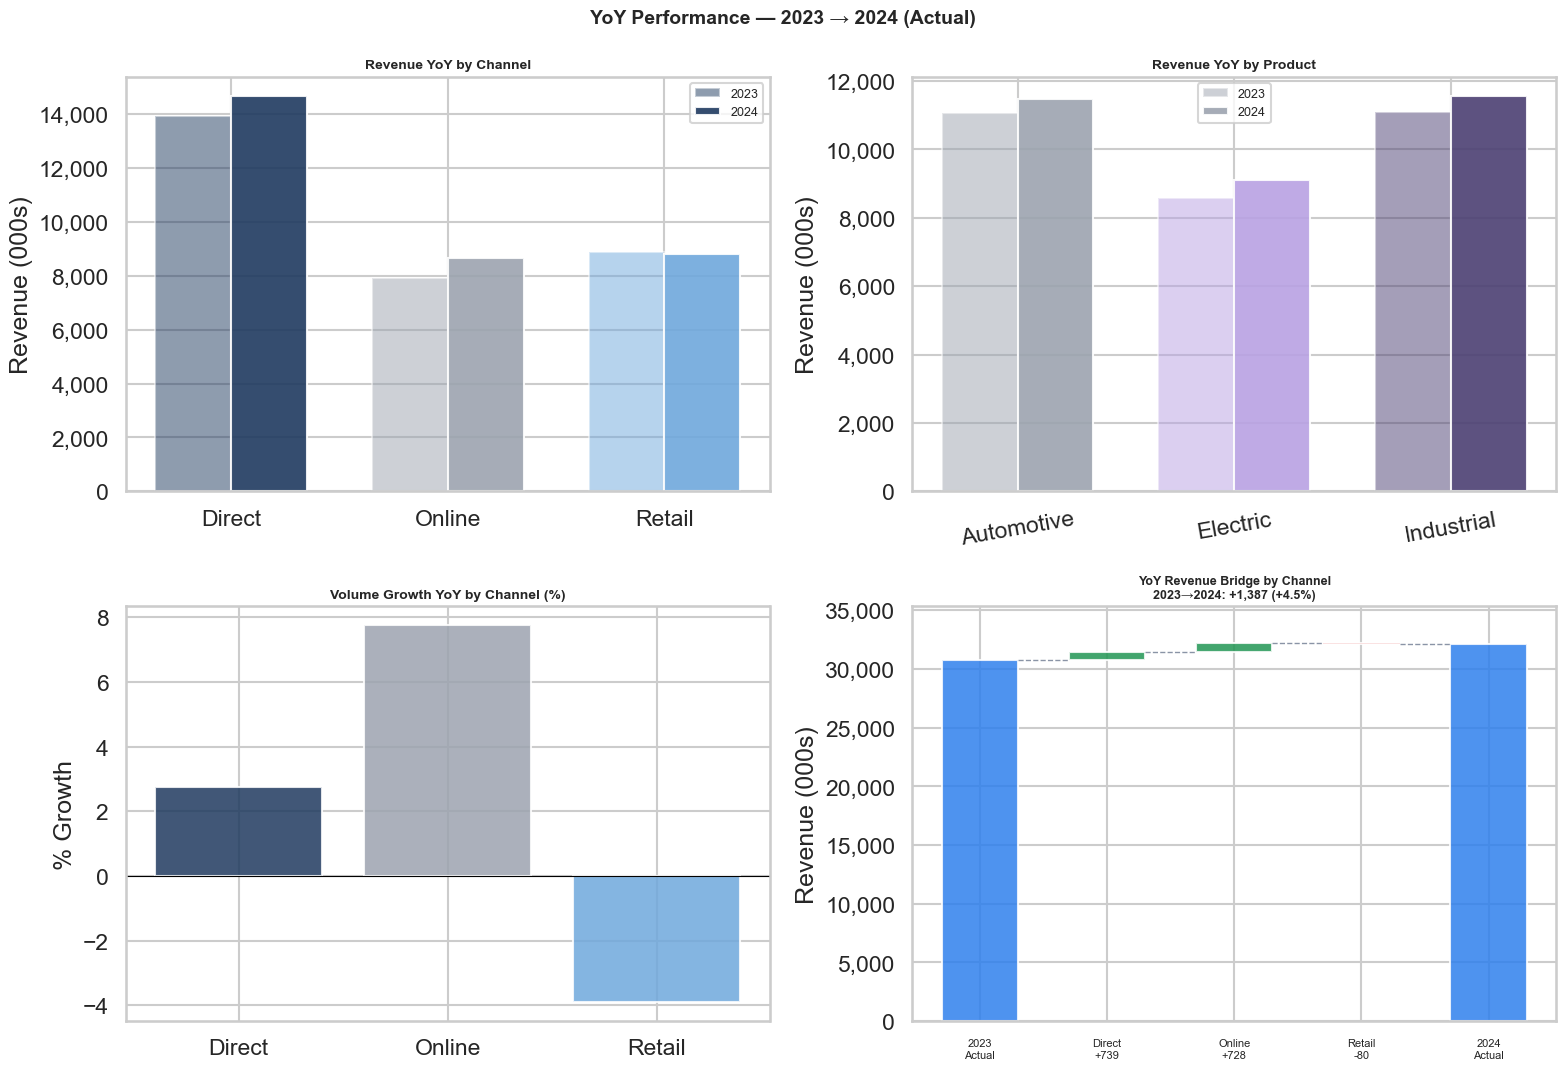

In [31]:
# ── YoY bridge from 2023 actual to 2024 actual ─────────────────────────────
# Revenue components using actual data from reg.csv
reg_23 = actual_pv[actual_pv['Year'] == 2023]
reg_24 = actual_pv[actual_pv['Year'] == 2024]

# Annual totals by channel and product
yoy_ch = pd.DataFrame({
    '2023': reg_23.groupby('Channel')['Rev_act'].sum(),
    '2024': reg_24.groupby('Channel')['Rev_act'].sum()
}).assign(Growth=lambda d: (d['2024']/d['2023']-1)*100,
          Delta=lambda d: d['2024']-d['2023'])

yoy_pr = pd.DataFrame({
    '2023': reg_23.groupby('Product')['Rev_act'].sum(),
    '2024': reg_24.groupby('Product')['Rev_act'].sum()
}).assign(Growth=lambda d: (d['2024']/d['2023']-1)*100,
          Delta=lambda d: d['2024']-d['2023'])

# Volume by channel YoY
yoy_vol_ch = pd.DataFrame({
    '2023_vol': reg_23.groupby('Channel')['Units_act'].sum(),
    '2024_vol': reg_24.groupby('Channel')['Units_act'].sum()
}).assign(Vol_growth=lambda d: (d['2024_vol']/d['2023_vol']-1)*100)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('YoY Performance — 2023 → 2024 (Actual)', fontsize=14, fontweight='bold')

# Revenue YoY by channel
ax = axes[0, 0]
x = np.arange(3); w = 0.35
ax.bar(x - w/2, yoy_ch['2023'], width=w, color=[CH_COLORS[c] for c in yoy_ch.index],
       alpha=0.5, label='2023', edgecolor='white')
bars = ax.bar(x + w/2, yoy_ch['2024'], width=w, color=[CH_COLORS[c] for c in yoy_ch.index],
              alpha=0.9, label='2024', edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(yoy_ch.index)
ax.set_title('Revenue YoY by Channel', fontsize=10, fontweight='bold')
ax.set_ylabel('Revenue (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=9)

# Revenue YoY by product
ax = axes[0, 1]
ax.bar(x - w/2, yoy_pr['2023'], width=w, color=[PR_COLORS[p] for p in yoy_pr.index],
       alpha=0.5, label='2023', edgecolor='white')
bars = ax.bar(x + w/2, yoy_pr['2024'], width=w, color=[PR_COLORS[p] for p in yoy_pr.index],
              alpha=0.9, label='2024', edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(yoy_pr.index, rotation=10)
ax.set_title('Revenue YoY by Product', fontsize=10, fontweight='bold')
ax.set_ylabel('Revenue (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.legend(fontsize=9)

# Volume YoY by channel
ax = axes[1, 0]
bars = ax.bar(yoy_vol_ch.index, yoy_vol_ch['Vol_growth'],
              color=[CH_COLORS[c] for c in yoy_vol_ch.index], alpha=0.85, edgecolor='white')

ax.axhline(0, color='black', lw=0.8)
ax.set_title('Volume Growth YoY by Channel (%)', fontsize=10, fontweight='bold')
ax.set_ylabel('% Growth')

# YoY revenue waterfall (total)
ax = axes[1, 1]
rev23  = yoy_ch['2023'].sum()
rev24  = yoy_ch['2024'].sum()
delta  = rev24 - rev23
price_yoy = 0  # pure volume/mix YoY since prices changed structurally
# Decompose by channel contribution
ch_deltas = yoy_ch['Delta'].values
ch_labels_yoy = [f'{c}\n{d:+,.0f}' for c, d in zip(yoy_ch.index, ch_deltas)]

all_labels = ['2023\nActual'] + ch_labels_yoy + ['2024\nActual']
running = rev23
bottoms = [0, rev23, rev23+ch_deltas[0], rev23+ch_deltas[0]+ch_deltas[1]]
heights_yoy = [rev23] + list(ch_deltas) + [rev24]
colors_yoy  = [BLUE] + [GREEN if v>=0 else RED for v in ch_deltas] + [BLUE]

for i, (h, bot, col) in enumerate(zip(heights_yoy, bottoms+[0], colors_yoy)):
    if i == 0 or i == 4:
        ax.bar(i, h, color=col, alpha=0.85, width=0.6, edgecolor='white')
    else:
        ax.bar(i, abs(h), bottom=min(bot, bot+h), color=col, alpha=0.85, width=0.6, edgecolor='white')
    if i < 4:
        nxt = (bot+h) if i>0 else h
        ax.plot([i+0.3, i+0.7], [nxt, nxt], color=GREY, lw=1, ls='--')

ax.set_xticks(range(5)); ax.set_xticklabels(all_labels, fontsize=8)
ax.set_title(f'YoY Revenue Bridge by Channel\n2023→2024: {delta:+,.0f} ({delta/rev23*100:+.1f}%)',
             fontsize=9, fontweight='bold')
ax.set_ylabel('Revenue (000s)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax.set_ylim(0, max(rev23, rev24) * 1.1)

plt.tight_layout()
plt.show()

### 17 — Executive FP&A Summary

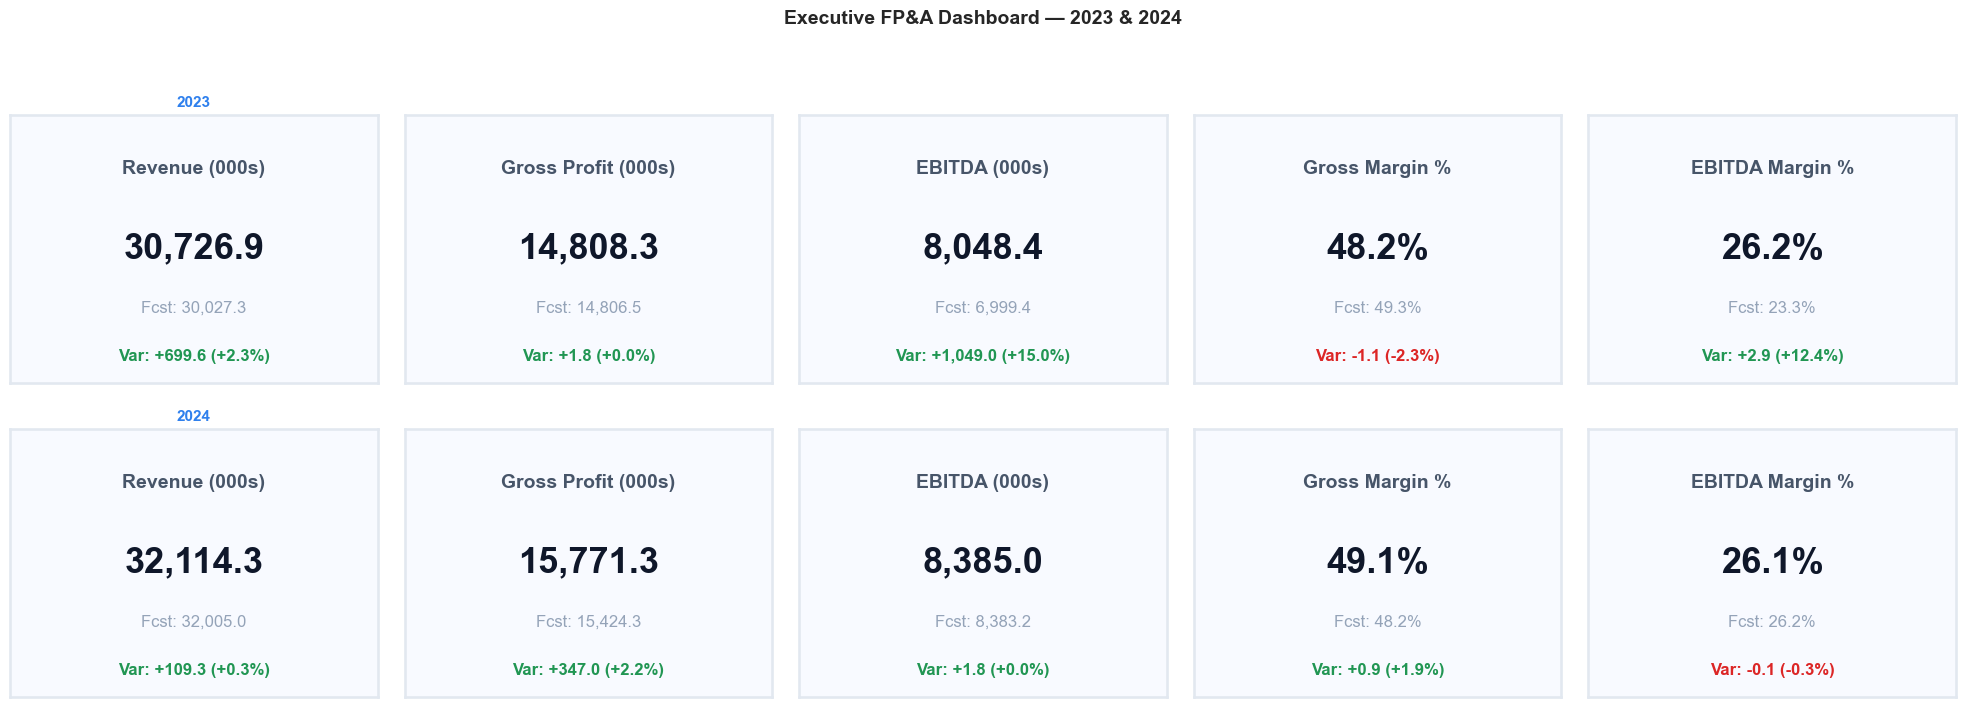

In [32]:
# ── KPI cards ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('Executive FP&A Dashboard — 2023 & 2024', fontsize=14, fontweight='bold', y=1.02)

def kpi_card(ax, title, val_act, val_fcst, fmt=',.1f', unit='', is_pct=False):
    var    = val_act - val_fcst
    var_pct= var / abs(val_fcst) * 100
    color  = GREEN if var >= 0 else RED
    ax.set_facecolor('#F8FAFF')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_edgecolor('#E2E8F0')
    ax.text(0.5, 0.80, title,         transform=ax.transAxes, ha='center', va='center',
            fontsize=14,  color='#475569', fontweight='bold')
    val_str = f'{val_act:{fmt}}{unit}' + ('%' if is_pct else '')
    ax.text(0.5, 0.50, val_str,        transform=ax.transAxes, ha='center', va='center',
            fontsize=26, color='#0F172A', fontweight='bold')
    fcst_str= f'Fcst: {val_fcst:{fmt}}{unit}' + ('%' if is_pct else '')
    ax.text(0.5, 0.28, fcst_str,       transform=ax.transAxes, ha='center', va='center',
            fontsize=12,  color='#94A3B8')
    var_str = f'Var: {var:+{fmt}}{unit} ({var_pct:+.1f}%)'
    ax.text(0.5, 0.10, var_str,        transform=ax.transAxes, ha='center', va='center',
            fontsize=12,  color=color, fontweight='bold')

for row_ax, yr in zip([axes[0], axes[1]], [2023, 2024]):
    yr_mb  = monthly_bridge[monthly_bridge['Year'] == yr]
    rev_a  = yr_mb['Rev_act'].sum()
    rev_f  = yr_mb['Rev_fcst'].sum()
    gp_a   = pl_bridge.loc[yr, 'GP_act']
    gp_f   = pl_bridge.loc[yr, 'GP_fcst']
    eb_a   = pl_bridge.loc[yr, 'EBITDA_act']
    eb_f   = pl_bridge.loc[yr, 'EBITDA_fcst']
    gm_a   = pl_bridge.loc[yr, 'GM_pct_act']
    gm_f   = pl_bridge.loc[yr, 'GM_pct_fcst']
    em_a   = pl_bridge.loc[yr, 'EBITDA_pct_act']
    em_f   = pl_bridge.loc[yr, 'EBITDA_pct_fcst']

    row_ax[0].set_title(str(yr), fontsize=11, fontweight='bold', color=BLUE)
    kpi_card(row_ax[0], 'Revenue (000s)',    rev_a,  rev_f)
    kpi_card(row_ax[1], 'Gross Profit (000s)', gp_a, gp_f)
    kpi_card(row_ax[2], 'EBITDA (000s)',     eb_a,   eb_f)
    kpi_card(row_ax[3], 'Gross Margin %',    gm_a,   gm_f,  fmt='.1f', is_pct=True)
    kpi_card(row_ax[4], 'EBITDA Margin %',   em_a,   em_f,  fmt='.1f', is_pct=True)

plt.tight_layout()
plt.show()

### 18 — Board Narrative: FP&A Variance Attribution

In [33]:
# Consolidated variance attribution table
ch_var_23 = bridge_23.groupby('Channel').apply(
    lambda d: pd.Series({'Rev_var': d['Rev_act'].sum() - d['Rev_fcst'].sum(),
                          'Vol_var': compute_bridge(d)['Vol_eff'],
                          'Mix_var': compute_bridge(d)['Mix_eff']})
)

pr_var_23 = bridge_23.groupby('Product').apply(
    lambda d: pd.Series({'Rev_var': d['Rev_act'].sum() - d['Rev_fcst'].sum(),
                          'Vol_var': compute_bridge(d)['Vol_eff'],
                          'Mix_var': compute_bridge(d)['Mix_eff']})
)

print('=' * 65)
print('  BOARD EXECUTIVE SUMMARY - FP&A VARIANCE REPORT')
print('  Digital Finance, Forecasting & Analytics Platform')
print('=' * 65)

for yr in [2023, 2024]:
    yr_mb = monthly_bridge[monthly_bridge['Year'] == yr]
    rev_a = yr_mb['Rev_act'].sum()
    rev_f = yr_mb['Rev_fcst'].sum()
    rev_var = rev_a - rev_f
    b = b23_total if yr == 2023 else b24_total
    risk = fpna_risk_matrix[fpna_risk_matrix['Year'] == yr]['Severity'].iloc[0]

    print(f'\n-- {yr} --------------------------------------------------')
    print(f'  Revenue   Actual: {rev_a:>10,.0f}  |  Forecast: {rev_f:>10,.0f}  |  Var: {rev_var:>+8,.0f}  ({rev_var/rev_f*100:+.1f}%)')
    print(f'  Price Effect : {b["Price_eff"]:>+8,.0f}')
    print(f'  Volume Effect: {b["Vol_eff"]:>+8,.0f}  ({b["Unit_var_pct"]:+.1f}% units)')
    print(f'  Mix Effect   : {b["Mix_eff"]:>+8,.0f}')

    if yr == 2023:
        print('  Channel Highlights:')
        for ch, row in ch_var_23.iterrows():
            flag = 'UP' if row['Rev_var'] >= 0 else 'DOWN'
            print(f'    {flag:<4} {ch:<10}: {row["Rev_var"]:>+8,.0f}')
        print('  Product Highlights:')
        for pr, row in pr_var_23.iterrows():
            flag = 'UP' if row['Rev_var'] >= 0 else 'DOWN'
            print(f'    {flag:<4} {pr:<12}: {row["Rev_var"]:>+8,.0f}')

    gp_a = pl_bridge.loc[yr, 'GP_act']; gp_f = pl_bridge.loc[yr, 'GP_fcst']
    eb_a = pl_bridge.loc[yr, 'EBITDA_act']; eb_f = pl_bridge.loc[yr, 'EBITDA_fcst']
    ni_a = pl_bridge.loc[yr, 'NetIncome_act']; ni_f = pl_bridge.loc[yr, 'NetIncome_fcst']
    print(f'  Gross Profit  Actual: {gp_a:>10,.0f}  |  Forecast: {gp_f:>10,.0f}  |  Var: {gp_a-gp_f:>+8,.0f}')
    print(f'  EBITDA        Actual: {eb_a:>10,.0f}  |  Forecast: {eb_f:>10,.0f}  |  Var: {eb_a-eb_f:>+8,.0f}  ({(eb_a-eb_f)/eb_f*100:+.1f}%)')
    print(f'  Net Income    Actual: {ni_a:>10,.0f}  |  Forecast: {ni_f:>10,.0f}  |  Var: {ni_a-ni_f:>+8,.0f}  ({(ni_a-ni_f)/ni_f*100:+.1f}%)')
    print(f'  Gross Margin  Actual: {pl_bridge.loc[yr,"GM_pct_act"]:>9.1f}%  |  Forecast: {pl_bridge.loc[yr,"GM_pct_fcst"]:>9.1f}%')
    print(f'  EBITDA Margin Actual: {pl_bridge.loc[yr,"EBITDA_pct_act"]:>9.1f}%  |  Forecast: {pl_bridge.loc[yr,"EBITDA_pct_fcst"]:>9.1f}%')
    print(f'  FP&A Severity : {risk}')

print('\n-- YoY (2023 to 2024) ------------------------------------')
rev23 = monthly_bridge[monthly_bridge['Year'] == 2023]['Rev_act'].sum()
rev24 = monthly_bridge[monthly_bridge['Year'] == 2024]['Rev_act'].sum()
print(f'  Revenue Growth: {rev24-rev23:+,.0f} ({(rev24/rev23-1)*100:+.1f}%)')
print(f'  Price increases implemented: Electric +3.0%, Automotive +2.0%, Industrial +2.0%')
print(f'  2024 Execution: tight variance ({(rev24/monthly_bridge[monthly_bridge["Year"]==2024]["Rev_fcst"].sum()-1)*100:+.2f}% vs plan)')

print('\n-- Scenario Risk Envelope --------------------------------')
for col, lbl in [('P10', 'Stress (P10)'), ('P30', 'Pessimistic (P30)'),
                 ('Rev_fcst', 'Base'), ('P70', 'Optimistic (P70)')]:
    ann = sc_annual[col].to_dict()
    print(f'  {lbl:<20}: 2023={ann[2023]:>9,.0f}  |  2024={ann[2024]:>9,.0f}')
print(f'  ACTUAL                : 2023={sc_annual["Rev_act"][2023]:>9,.0f}  |  2024={sc_annual["Rev_act"][2024]:>9,.0f}')

log.info('Module 4.5 - FP&A Bridge Analysis - COMPLETE')

2026-04-15 17:32:14,977 [INFO] Module 4.5 - FP&A Bridge Analysis - COMPLETE


  BOARD EXECUTIVE SUMMARY - FP&A VARIANCE REPORT
  Digital Finance, Forecasting & Analytics Platform

-- 2023 --------------------------------------------------
  Revenue   Actual:     30,727  |  Forecast:     30,027  |  Var:     +700  (+2.3%)
  Price Effect :       +0
  Volume Effect:     +625  (+2.1% units)
  Mix Effect   :      +74
  Channel Highlights:
    UP   Direct    :     +330
    UP   Online    :     +672
    DOWN Retail    :     -303
  Product Highlights:
    UP   Automotive  :     +135
    UP   Electric    :     +296
    UP   Industrial  :     +269
  Gross Profit  Actual:     14,808  |  Forecast:     14,806  |  Var:       +2
  EBITDA        Actual:      8,048  |  Forecast:      6,999  |  Var:   +1,049  (+15.0%)
  Net Income    Actual:      4,286  |  Forecast:      3,547  |  Var:     +739  (+20.8%)
  Gross Margin  Actual:      48.2%  |  Forecast:      49.3%
  EBITDA Margin Actual:      26.2%  |  Forecast:      23.3%
  FP&A Severity : ALERT

-- 2024 --------------------------